# Feature Engineering y Experimentos A/B

## Configuración

In [1]:
import warnings, os, json, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import f_classif
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, precision_recall_curve,
                             roc_curve, auc, silhouette_score)
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

# ---- Roster de modelos (mismo orden y colores que Sprints 0 y 1) ----
MODEL_COLORS = {
    'KNN':                  'blue',
    'Reg. Logística':       'orange',
    'SVM (RBF)':            'teal',
    'MLP':                  'magenta',
    'Árbol de Decisión':    'green',
    'Random Forest':        'red',
    'ExtraTrees':           'olive',
    'HistGradientBoosting': 'brown',
    'XGBoost':              'purple',
    'LightGBM':             'darkcyan',
    'CatBoost':             'goldenrod',
}
MODELOS = list(MODEL_COLORS.keys())

# ---- Datos y split (idénticos a Sprints 0 y 1) ----
df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']   # sin Au, sin coordenadas
FEATURES_BASE = [c for c in df.columns if c not in EXCLUIR]
X = df[FEATURES_BASE].copy()
y = df['target_Au'].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

# ---- Resultados del Sprint 1: F1 de partida y mejor balanceo por modelo ----
with open('outputs_sprint1/resumen_sprint1.json') as f:
    RESUMEN_S1 = json.load(f)

with open('outputs_sprint0/resumen_sprint0.json') as f:
    RESUMEN_S0 = json.load(f)
F1_SPRINT0 = RESUMEN_S0['f1_final']
F1_SPRINT1 = RESUMEN_S1['f1_final']
CONFIG_S1 = RESUMEN_S1['config_por_modelo']          # Baseline / Balanceo / PCA / Bal+PCA
f1_bal_s1 = pd.read_csv('outputs_sprint1/balanceo_f1.csv', index_col=0)

# El balanceo se aplica solo si ayudó en el Sprint 1 (config con 'Bal').
# El PCA no se traslada al Sprint 2: los experimentos A/B evalúan features
# interpretables (FE, clusters), no proyecciones.
BALANCEO_POR_MODELO = {}
for mod in MODELOS:
    if 'Bal' in CONFIG_S1.get(mod, 'Baseline'):
        BALANCEO_POR_MODELO[mod] = f1_bal_s1[mod].astype(float).idxmax()
    else:
        BALANCEO_POR_MODELO[mod] = 'Sin balanceo'

os.makedirs('outputs_sprint2', exist_ok=True)
print(f'Modelos: {len(MODELOS)} | Features base: {len(FEATURES_BASE)}')
print(f'Train: {X_train.shape} dist={y_train.value_counts().to_dict()}')
print(f'Test : {X_test.shape} dist={y_test.value_counts().to_dict()}')
print(f'F1 ganador Sprint 1: {F1_SPRINT1} ({RESUMEN_S1["mejor_modelo"]} + {RESUMEN_S1.get("metodo_balanceo", "-")})')
print('\nBalanceo heredado del Sprint 1 (por modelo):')
for mod in MODELOS:
    print(f'  {mod}: {BALANCEO_POR_MODELO[mod]} (config S1: {CONFIG_S1.get(mod, "?")})')

Modelos: 11 | Features base: 46
Train: (1705, 46) dist={0: 1497, 1: 208}
Test : (427, 46) dist={0: 375, 1: 52}
F1 ganador Sprint 1: 0.7736 (LightGBM + RandomOverSampler)

Balanceo heredado del Sprint 1 (por modelo):
  KNN: BorderlineSMOTE (config S1: Balanceo)
  Reg. Logística: Sin balanceo (config S1: PCA)
  SVM (RBF): SMOTETomek (config S1: Bal+PCA)
  MLP: Sin balanceo (config S1: Baseline)
  Árbol de Decisión: RandomOverSampler (config S1: Balanceo)
  Random Forest: SMOTE (config S1: Balanceo)
  ExtraTrees: SMOTE (config S1: Balanceo)
  HistGradientBoosting: RandomOverSampler (config S1: Balanceo)
  XGBoost: Sin balanceo (config S1: Baseline)
  LightGBM: RandomOverSampler (config S1: Balanceo)
  CatBoost: RandomOverSampler (config S1: Balanceo)


## Funciones

In [2]:
def crear_modelos():
    """11 modelos con configuración por defecto/ligera (mismo roster que Sprints 0 y 1)."""
    return {
        'KNN':                  Pipeline([('sc', StandardScaler()),
                                          ('clf', KNeighborsClassifier(n_neighbors=5))]),
        'Reg. Logística':       Pipeline([('sc', StandardScaler()),
                                          ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
        'SVM (RBF)':            Pipeline([('sc', StandardScaler()),
                                          ('clf', SVC(kernel='rbf', random_state=SEED))]),
        'MLP':                  Pipeline([('sc', StandardScaler()),
                                          ('clf', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500,
                                                                random_state=SEED))]),
        'Árbol de Decisión':    Pipeline([('sc', StandardScaler()),
                                          ('clf', DecisionTreeClassifier(random_state=SEED))]),
        'Random Forest':        Pipeline([('sc', StandardScaler()),
                                          ('clf', RandomForestClassifier(n_estimators=100, random_state=SEED,
                                                                         n_jobs=-1))]),
        'ExtraTrees':           Pipeline([('sc', StandardScaler()),
                                          ('clf', ExtraTreesClassifier(n_estimators=100, random_state=SEED,
                                                                       n_jobs=-1))]),
        'HistGradientBoosting': Pipeline([('sc', StandardScaler()),
                                          ('clf', HistGradientBoostingClassifier(random_state=SEED))]),
        'XGBoost':              Pipeline([('sc', StandardScaler()),
                                          ('clf', xgb.XGBClassifier(n_estimators=100, random_state=SEED,
                                                                    eval_metric='logloss',
                                                                    tree_method='hist', n_jobs=-1))]),
        'LightGBM':             Pipeline([('sc', StandardScaler()),
                                          ('clf', lgb.LGBMClassifier(n_estimators=100, random_state=SEED,
                                                                     verbose=-1, n_jobs=-1))]),
        'CatBoost':             Pipeline([('sc', StandardScaler()),
                                          ('clf', CatBoostClassifier(iterations=100, random_seed=SEED,
                                                                     allow_writing_files=False, verbose=0))]),
    }

def crear_balanceador(nombre):
    """Instancia nueva del balanceador (mismos métodos que el Sprint 1)."""
    return {
        'Sin balanceo':      None,
        'RandomOverSampler': RandomOverSampler(random_state=SEED),
        'SMOTE':             SMOTE(random_state=SEED, k_neighbors=5),
        'BorderlineSMOTE':   BorderlineSMOTE(random_state=SEED, k_neighbors=5),
        'ADASYN':            ADASYN(random_state=SEED),
        'SMOTETomek':        SMOTETomek(random_state=SEED),
    }[nombre]

def balancear(mod, Xtr, ytr):
    """Aplica el mejor balanceo del Sprint 1 para el modelo (o nada)."""
    bal = crear_balanceador(BALANCEO_POR_MODELO[mod])
    if bal is None:
        return Xtr, ytr
    return bal.fit_resample(Xtr, ytr)

def scores_pos(modelo, Xte):
    clf = modelo.named_steps['clf'] if hasattr(modelo, 'named_steps') else modelo
    if hasattr(clf, 'predict_proba'):
        return modelo.predict_proba(Xte)[:, 1]
    return modelo.decision_function(Xte)

def entrenar_evaluar(mod, Xtr, ytr, Xte, yte, clf=None):
    """Balancea el train según el Sprint 1, entrena y evalúa en hold-out."""
    modelo = crear_modelos()[mod] if clf is None else clf
    Xb, yb = balancear(mod, Xtr, ytr)
    modelo.fit(Xb, yb)
    pred = modelo.predict(Xte)
    sco = scores_pos(modelo, Xte)
    return {'F1': f1_score(yte, pred), 'Accuracy': accuracy_score(yte, pred),
            'Precision': precision_score(yte, pred, zero_division=0),
            'Recall': recall_score(yte, pred), 'AUC-ROC': roc_auc_score(yte, sco),
            '_pred': pred, '_prob': sco, '_clf': modelo}
print('Funciones base listas.')

Funciones base listas.


## Feature importances

In [3]:
IMP_NATIVA = ['Árbol de Decisión', 'Random Forest', 'ExtraTrees', 'XGBoost', 'LightGBM', 'CatBoost']
IMP_COEF = ['Reg. Logística']
IMP_PERM = ['KNN', 'SVM (RBF)', 'MLP', 'HistGradientBoosting']

imp_df = pd.DataFrame(index=FEATURES_BASE, dtype=float)
modelos_rapidos = {}
for mod in MODELOS:
    t0 = time.time()
    modelo = crear_modelos()[mod]
    Xb, yb = balancear(mod, X_train, y_train)
    modelo.fit(Xb, yb)
    modelos_rapidos[mod] = modelo
    if mod in IMP_NATIVA:
        imp = np.asarray(modelo.named_steps['clf'].feature_importances_, dtype=float)
        fuente = 'nativa'
    elif mod in IMP_COEF:
        imp = np.abs(modelo.named_steps['clf'].coef_).ravel()
        fuente = '|coef|'
    else:
        r = permutation_importance(modelo, X_test, y_test, scoring='f1',
                                   n_repeats=5, random_state=SEED, n_jobs=-1)
        imp = np.clip(r.importances_mean, 0, None)   # negativas -> 0 (ruido)
        fuente = 'permutación'
    imp = imp / imp.sum() if imp.sum() > 0 else imp
    imp_df[mod] = imp
    print(f'  {mod} ({fuente}): OK ({time.time()-t0:.1f}s)')

imp_df['Consenso'] = imp_df[MODELOS].mean(axis=1)
imp_df = imp_df.sort_values('Consenso', ascending=False)
imp_df.round(5).to_csv('outputs_sprint2/importancias_consenso.csv')
RANKING = list(imp_df.index)
print('\nTop-10 del ranking consensuado:')
display(imp_df[['Consenso']].head(10).round(4))

  KNN (permutación): OK (8.2s)
  Reg. Logística (|coef|): OK (0.1s)
  SVM (RBF) (permutación): OK (8.5s)
  MLP (permutación): OK (4.2s)
  Árbol de Decisión (nativa): OK (0.1s)
  Random Forest (nativa): OK (0.9s)
  ExtraTrees (nativa): OK (0.4s)
  HistGradientBoosting (permutación): OK (2.5s)
  XGBoost (nativa): OK (0.8s)
  LightGBM (nativa): OK (0.7s)
  CatBoost (nativa): OK (1.1s)

Top-10 del ranking consensuado:


,Consenso
Ag_ppm,0.2072
Sb_ppm,0.0375
Be_ppm,0.0373
As_ppm,0.0368
Al_per,0.0305
Cs_ppm,0.0290
Rb_ppm,0.0290
Te_ppm,0.0282
Ce_ppm,0.0231
U_ppm,0.0215


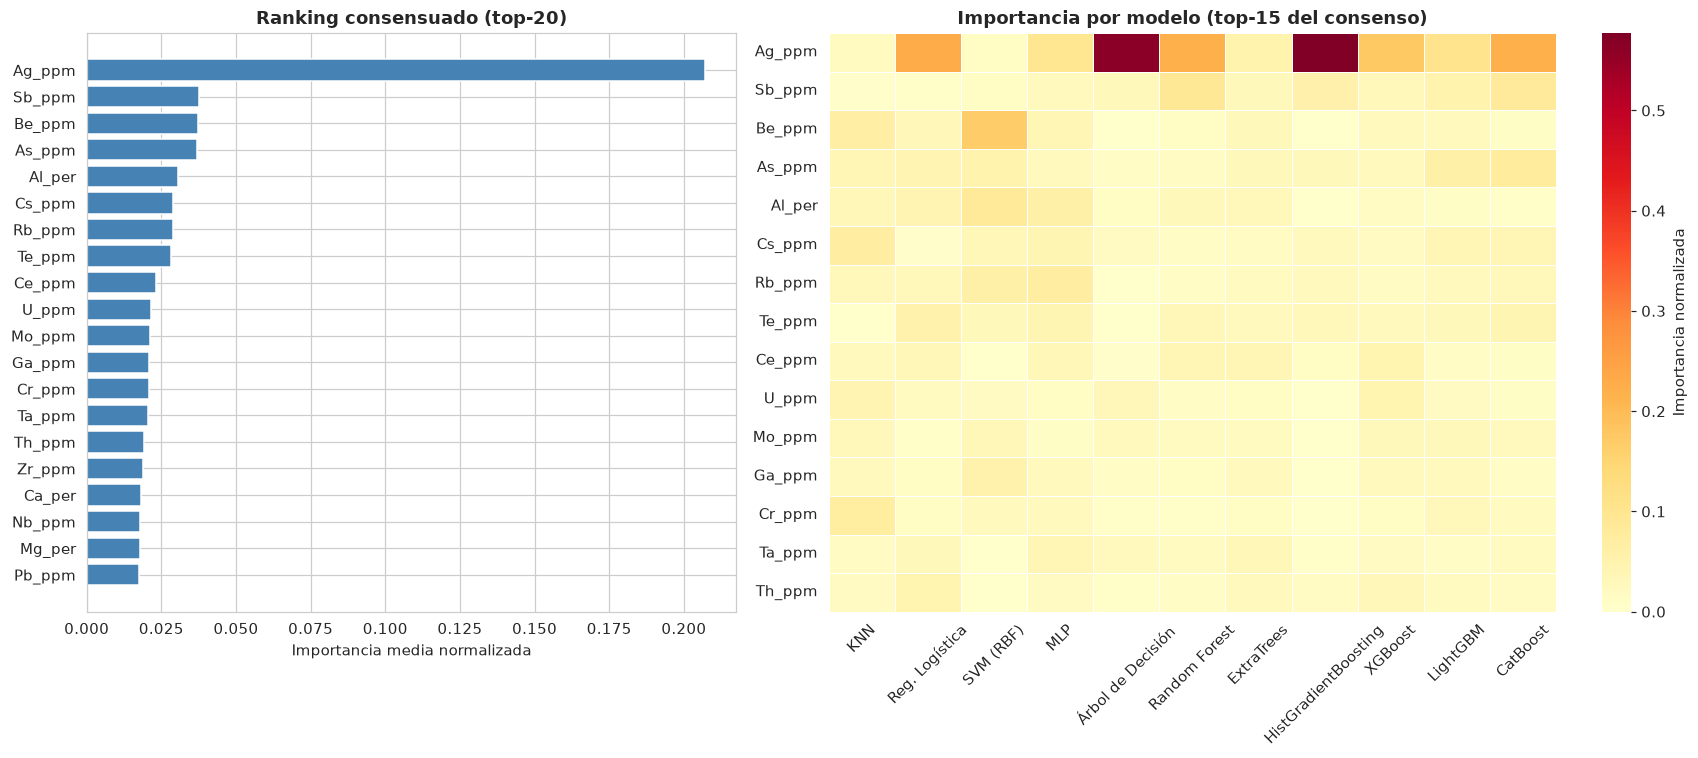

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1.4]})
top20 = imp_df['Consenso'].head(20)[::-1]
axes[0].barh(top20.index, top20.values, color='steelblue')
axes[0].set_title('Ranking consensuado (top-20)', fontweight='bold')
axes[0].set_xlabel('Importancia media normalizada')

top15 = imp_df.head(15)
sns.heatmap(top15[MODELOS], ax=axes[1], cmap='YlOrRd', linewidths=.4,
            cbar_kws={'label': 'Importancia normalizada'})
axes[1].set_title('Importancia por modelo (top-15 del consenso)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig('outputs_sprint2/importancias_consenso.png', bbox_inches='tight'); plt.show()

## Feature Engineering

In [5]:
# Elementos económicos: co-ocurren con Au -> se EXCLUYEN del FE (no del dataset)
ELEM_ECONOMICOS = ['Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm']
RANKING_NO_ECON = [e for e in RANKING if e not in ELEM_ECONOMICOS]
TOP_ELEM = RANKING_NO_ECON[:10]
print('Elementos económicos excluidos del FE:', ELEM_ECONOMICOS)
print(f'Top-{len(TOP_ELEM)} elementos NO económicos del consenso (base de los ratios):', TOP_ELEM)

def nombre_ratio(a, b):
    return f"{a.replace('_ppm','')}_{b.replace('_ppm','')}_ratio"

# 1) candidatos: todos los pares del top-8
cand_ratios = {}
for a, b in combinations(TOP_ELEM, 2):
    cand_ratios[nombre_ratio(a, b)] = (a, b)

# 2) puntuar con F de ANOVA en TRAIN (imputando division por cero con la mediana)
mat = pd.DataFrame(index=X_train.index)
for nom, (nu, de) in cand_ratios.items():
    r = X_train[nu] / X_train[de].replace(0, np.nan)
    mat[nom] = r.replace([np.inf, -np.inf], np.nan).fillna(r.median())
F_stats, _ = f_classif(mat, y_train)
score_ratios = pd.Series(F_stats, index=mat.columns).sort_values(ascending=False)
score_ratios.to_csv('outputs_sprint2/ratios_score_anova.csv', header=['F_anova'])

# 3) top-10 ratios
N_RATIOS = 10
RATIOS = {nom: cand_ratios[nom] for nom in score_ratios.head(N_RATIOS).index}
print(f'\nRatios seleccionados (top-{N_RATIOS} por F de ANOVA de {len(cand_ratios)} candidatos):')
display(score_ratios.head(N_RATIOS).round(1).to_frame('F_anova'))

# elementos sesgados en TRAIN (skew > 2) -> log1p
skews = X_train.skew().sort_values(ascending=False)
COLS_LOG = list(skews[skews > 2].index)
print(f'Elementos con skew > 2 (log1p): {len(COLS_LOG)}')
print(COLS_LOG)

def aplicar_fe(Xdf, medianas=None):
    """Ratios dirigidos + log1p. Las medianas para imputar se calculan SOLO en train."""
    out = Xdf.copy()
    for nom, (nu, de) in RATIOS.items():
        out[nom] = (Xdf[nu] / Xdf[de].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
    for c in COLS_LOG:
        out[f'log_{c}'] = np.log1p(Xdf[c].clip(lower=0))
    cols_ratio = list(RATIOS)
    if medianas is None:
        medianas = out[cols_ratio].median()
    out[cols_ratio] = out[cols_ratio].fillna(medianas)
    return out, medianas

X_train_fe, MED_TRAIN = aplicar_fe(X_train)
X_test_fe, _ = aplicar_fe(X_test, MED_TRAIN)
FEATURES_FE_NUEVAS = [c for c in X_train_fe.columns if c not in FEATURES_BASE]
print(f'\nFeatures FE nuevas: {len(FEATURES_FE_NUEVAS)} → total set FE: {X_train_fe.shape[1]}')

Elementos económicos excluidos del FE: ['Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm']
Top-10 elementos NO económicos del consenso (base de los ratios): ['Sb_ppm', 'Be_ppm', 'As_ppm', 'Al_per', 'Cs_ppm', 'Rb_ppm', 'Te_ppm', 'Ce_ppm', 'U_ppm', 'Mo_ppm']

Ratios seleccionados (top-10 por F de ANOVA de 45 candidatos):


,F_anova
Sb_U_ratio,194.8
Al_per_Te_ratio,177.3
Rb_U_ratio,156.3
Sb_Ce_ratio,135.1
Te_U_ratio,117.2
Be_Te_ratio,115.8
Sb_Be_ratio,114.3
Rb_Ce_ratio,110.7
Be_U_ratio,107.9
Cs_U_ratio,104.0


Elementos con skew > 2 (log1p): 28
['Co_ppm', 'Bi_ppm', 'Ag_ppm', 'Cd_ppm', 'Se_ppm', 'Sb_ppm', 'Te_ppm', 'Cu_ppm', 'Ni_ppm', 'W_ppm', 'Sn_ppm', 'Mn_ppm', 'Re_ppm', 'As_ppm', 'Pb_ppm', 'S_per', 'Zn_ppm', 'Mo_ppm', 'Fe_per', 'Ba_ppm', 'Tl_ppm', 'Ge_ppm', 'Ca_per', 'Mg_per', 'Sr_ppm', 'Cs_ppm', 'Cr_ppm', 'U_ppm']

Features FE nuevas: 38 → total set FE: 84


## Analisis VIF

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# candidatos FE: ratios + logs + agregados (estos últimos solo para demostrar su exclusión)
cand = X_train_fe[FEATURES_FE_NUEVAS].copy()
# Pathfinders: top-N no económicos del ranking consensuado (automático, no hardcodeado)
pathf = RANKING_NO_ECON[:10]
cand['pathfinder_sum']  = X_train[pathf].sum(axis=1)
cand['pathfinder_mean'] = X_train[pathf].mean(axis=1)
cand['pathfinder_max']  = X_train[pathf].max(axis=1)

Z = pd.DataFrame(StandardScaler().fit_transform(cand), columns=cand.columns)
vif = pd.DataFrame({'Feature': Z.columns,
                    'VIF': [variance_inflation_factor(Z.values, i) for i in range(Z.shape[1])]})
vif['Tipo'] = np.where(vif['Feature'].str.startswith('pathfinder'), 'Agregado',
              np.where(vif['Feature'].str.startswith('log_'), 'Log', 'Ratio'))
vif['Decisión'] = np.where(vif['VIF'] > 10, 'EXCLUIR (VIF>10)', 'Mantener')
vif = vif.sort_values('VIF', ascending=False).reset_index(drop=True)
vif.to_csv('outputs_sprint2/VIF.csv', index=False)
print('VIF de candidatos FE (umbral de exclusión: VIF > 10):')
display(vif.round(2))
excluir_vif = vif.loc[(vif['VIF'] > 10) & (~vif['Feature'].str.startswith('pathfinder')), 'Feature'].tolist()
if excluir_vif:
    print('Features FE excluidas por VIF>10:', excluir_vif)
    FEATURES_FE_NUEVAS = [c for c in FEATURES_FE_NUEVAS if c not in excluir_vif]
    X_train_fe = X_train_fe.drop(columns=excluir_vif)
    X_test_fe = X_test_fe.drop(columns=excluir_vif)
print(f'Set FE final: {X_train_fe.shape[1]} features ({len(FEATURES_FE_NUEVAS)} nuevas)')

VIF de candidatos FE (umbral de exclusión: VIF > 10):


,Feature,VIF,Tipo,Decisión
0,pathfinder_mean,inf,Agregado,EXCLUIR (VIF>10)
1,pathfinder_sum,inf,Agregado,EXCLUIR (VIF>10)
2,pathfinder_max,210.66,Agregado,EXCLUIR (VIF>10)
3,log_Co_ppm,7.88,Log,Mantener
4,Al_per_Te_ratio,7.09,Ratio,Mantener
5,Be_Te_ratio,7.06,Ratio,Mantener
6,log_Sr_ppm,6.68,Log,Mantener
7,Cs_U_ratio,6.14,Ratio,Mantener
8,log_Ni_ppm,5.85,Log,Mantener
9,Rb_U_ratio,5.54,Ratio,Mantener


Set FE final: 84 features (38 nuevas)


## Clustering

Espacio base para clustering: 42 cols (de 46)
Espacio FE para clustering:   76 cols (de 84)


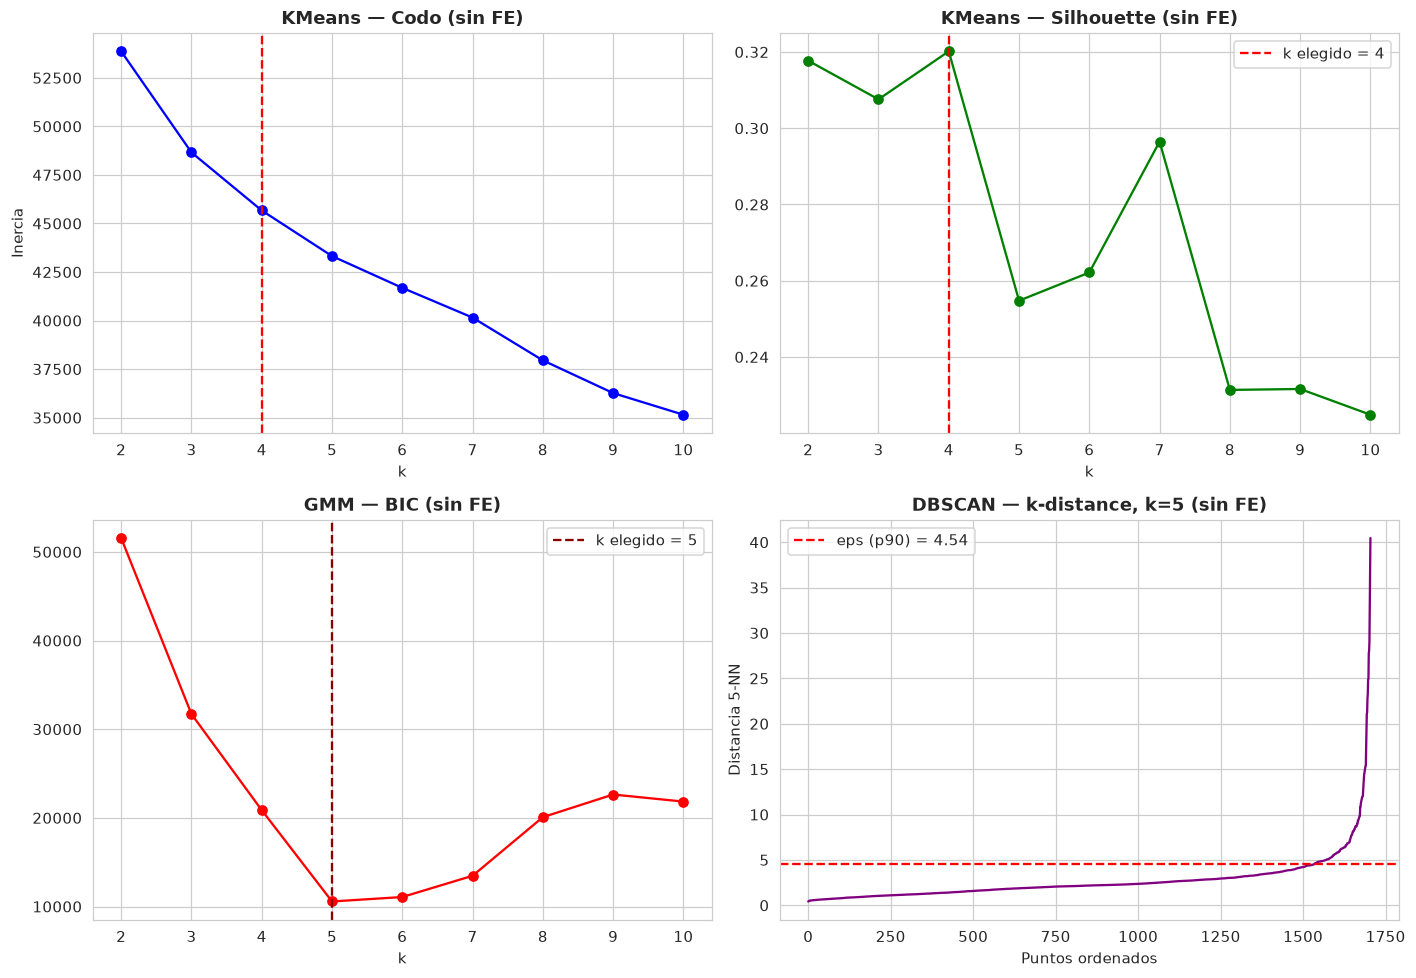

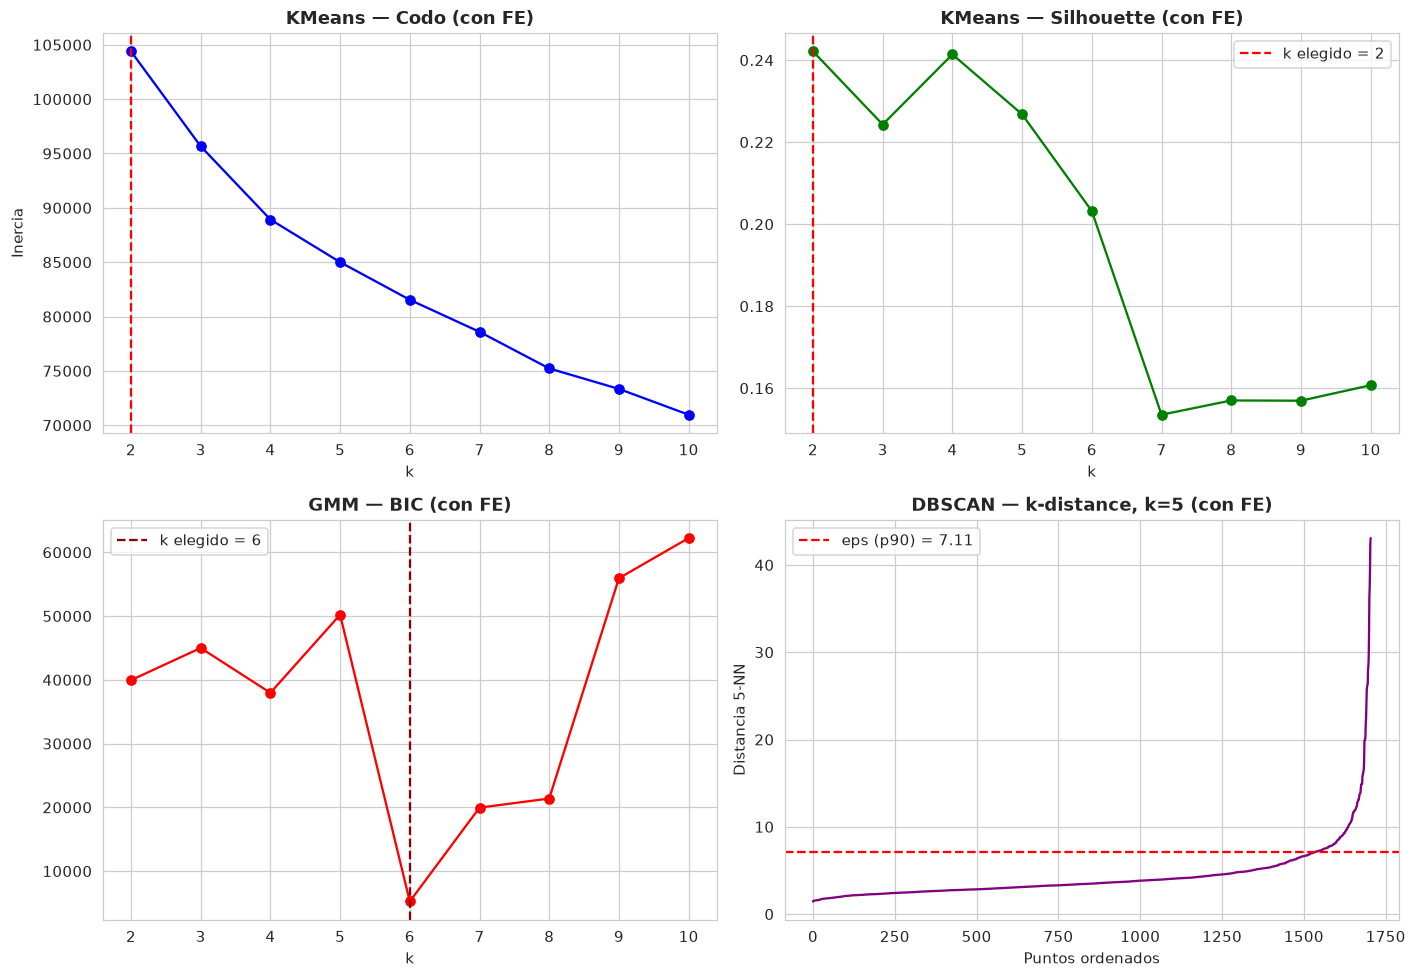

,k KMeans,Silhouette,k GMM,eps DBSCAN
Espacio,,,,
Sin FE,4,0.3202,5,4.541
Con FE,2,0.2421,6,7.110


In [7]:
def seleccionar_clustering(Xtr, etiqueta, fname):
    """Selecciona k de KMeans (silhouette), k de GMM (BIC) y eps de DBSCAN (k-distance p90)."""
    sc = StandardScaler().fit(Xtr)
    Xtr_sc = sc.transform(Xtr)
    ks = list(range(2, 11))
    inercias, silus, bics = [], [], []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Xtr_sc)
        inercias.append(km.inertia_)
        silus.append(silhouette_score(Xtr_sc, km.labels_))
        bics.append(GaussianMixture(n_components=k, random_state=SEED, n_init=3).fit(Xtr_sc).bic(Xtr_sc))
    k_km = ks[int(np.argmax(silus))]
    k_gm = ks[int(np.argmin(bics))]
    nn5 = NearestNeighbors(n_neighbors=5).fit(Xtr_sc)
    d5 = np.sort(nn5.kneighbors(Xtr_sc)[0][:, -1])
    eps = float(np.percentile(d5, 90))

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes[0,0].plot(ks, inercias, marker='o', color='blue')
    axes[0,0].axvline(k_km, ls='--', color='red')
    axes[0,0].set_title(f'KMeans — Codo ({etiqueta})', fontweight='bold')
    axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inercia')
    axes[0,1].plot(ks, silus, marker='o', color='green')
    axes[0,1].axvline(k_km, ls='--', color='red', label=f'k elegido = {k_km}')
    axes[0,1].set_title(f'KMeans — Silhouette ({etiqueta})', fontweight='bold')
    axes[0,1].set_xlabel('k'); axes[0,1].legend()
    axes[1,0].plot(ks, bics, marker='o', color='red')
    axes[1,0].axvline(k_gm, ls='--', color='darkred', label=f'k elegido = {k_gm}')
    axes[1,0].set_title(f'GMM — BIC ({etiqueta})', fontweight='bold')
    axes[1,0].set_xlabel('k'); axes[1,0].legend()
    axes[1,1].plot(d5, color='purple')
    axes[1,1].axhline(eps, ls='--', color='red', label=f'eps (p90) = {eps:.2f}')
    axes[1,1].set_title(f'DBSCAN — k-distance, k=5 ({etiqueta})', fontweight='bold')
    axes[1,1].set_xlabel('Puntos ordenados'); axes[1,1].set_ylabel('Distancia 5-NN'); axes[1,1].legend()
    plt.tight_layout(); plt.savefig(fname, bbox_inches='tight'); plt.show()
    return {'scaler': sc, 'k_kmeans': k_km, 'silhouette': max(silus),
            'k_gmm': k_gm, 'eps': eps}

# Espacios de clustering SIN elementos económicos (ni sus transformaciones log)
LOG_ECON = [f'log_{e}' for e in ELEM_ECONOMICOS]
COLS_CLU_BASE = [c for c in X_train.columns if c not in ELEM_ECONOMICOS]
COLS_CLU_FE   = [c for c in X_train_fe.columns if c not in ELEM_ECONOMICOS + LOG_ECON]
print(f'Espacio base para clustering: {len(COLS_CLU_BASE)} cols (de {X_train.shape[1]})')
print(f'Espacio FE para clustering:   {len(COLS_CLU_FE)} cols (de {X_train_fe.shape[1]})')

SEL_BASE = seleccionar_clustering(X_train[COLS_CLU_BASE], 'sin FE', 'outputs_sprint2/clustering_seleccion_sinFE.png')
SEL_FE   = seleccionar_clustering(X_train_fe[COLS_CLU_FE], 'con FE', 'outputs_sprint2/clustering_seleccion_conFE.png')

tabla_sel = pd.DataFrame({
    'Espacio': ['Sin FE', 'Con FE'],
    'k KMeans': [SEL_BASE['k_kmeans'], SEL_FE['k_kmeans']],
    'Silhouette': [round(SEL_BASE['silhouette'], 4), round(SEL_FE['silhouette'], 4)],
    'k GMM': [SEL_BASE['k_gmm'], SEL_FE['k_gmm']],
    'eps DBSCAN': [round(SEL_BASE['eps'], 3), round(SEL_FE['eps'], 3)],
}).set_index('Espacio')
tabla_sel.to_csv('outputs_sprint2/clustering_seleccion.csv')
display(tabla_sel)

In [8]:
def derivar_features_clustering(sel, Xtr, Xte):
    """Ajusta KMeans/GMM/DBSCAN en train y deriva las 5 features para train y test."""
    Xtr_sc = sel['scaler'].transform(Xtr)
    Xte_sc = sel['scaler'].transform(Xte)
    km = KMeans(n_clusters=sel['k_kmeans'], random_state=SEED, n_init=10).fit(Xtr_sc)
    gm = GaussianMixture(n_components=sel['k_gmm'], random_state=SEED, n_init=3).fit(Xtr_sc)
    db = DBSCAN(eps=sel['eps'], min_samples=5).fit(Xtr_sc)
    # DBSCAN no tiene predict: en test, outlier = distancia al core más cercano > eps
    cores = Xtr_sc[db.core_sample_indices_]
    nn_core = NearestNeighbors(n_neighbors=1).fit(cores)
    def feats(Xsc, idx):
        return pd.DataFrame({
            'kmeans_label': km.predict(Xsc),
            'kmeans_dist':  km.transform(Xsc).min(axis=1),
            'gmm_label':    gm.predict(Xsc),
            'gmm_prob_max': gm.predict_proba(Xsc).max(axis=1),
            'dbscan_outlier': (nn_core.kneighbors(Xsc)[0][:, 0] > sel['eps']).astype(int),
        }, index=idx)
    return feats(Xtr_sc, Xtr.index), feats(Xte_sc, Xte.index)

CLU_TRAIN, CLU_TEST = derivar_features_clustering(
    SEL_BASE, X_train[COLS_CLU_BASE], X_test[COLS_CLU_BASE])            # espacio sin FE (no económico)
CLU_TRAIN_FE, CLU_TEST_FE = derivar_features_clustering(
    SEL_FE, X_train_fe[COLS_CLU_FE], X_test_fe[COLS_CLU_FE])            # espacio con FE (no económico)
FEATURES_CLU = list(CLU_TRAIN.columns)
print('Features de clustering:', FEATURES_CLU)
print(f"Outliers DBSCAN sin FE — train: {CLU_TRAIN['dbscan_outlier'].mean():.1%} | test: {CLU_TEST['dbscan_outlier'].mean():.1%}")
print(f"Outliers DBSCAN con FE — train: {CLU_TRAIN_FE['dbscan_outlier'].mean():.1%} | test: {CLU_TEST_FE['dbscan_outlier'].mean():.1%}")

Features de clustering: ['kmeans_label', 'kmeans_dist', 'gmm_label', 'gmm_prob_max', 'dbscan_outlier']
Outliers DBSCAN sin FE — train: 7.3% | test: 10.3%
Outliers DBSCAN con FE — train: 6.7% | test: 10.5%


In [9]:
comp = []
for nombre, clu in [('sin FE', CLU_TRAIN), ('con FE', CLU_TRAIN_FE)]:
    for col in ['kmeans_label', 'gmm_label', 'dbscan_outlier']:
        t = pd.crosstab(clu[col], y_train, normalize='index')
        t.columns = ['% Neg', '% Pos']
        t.insert(0, 'n', pd.crosstab(clu[col], y_train).sum(axis=1))
        t.index = [f'[{nombre}] {col}={i}' for i in t.index]
        comp.append(t)
tabla_comp = pd.concat(comp).round(3)
tabla_comp.to_csv('outputs_sprint2/clustering_composicion.csv')
print(f'Composición del target por cluster (train) — tasa base de positivos: {y_train.mean():.3f}')
tabla_comp

Composición del target por cluster (train) — tasa base de positivos: 0.122


,n,% Neg,% Pos
[sin FE] kmeans_label=0,28,0.393,0.607
[sin FE] kmeans_label=1,811,0.794,0.206
[sin FE] kmeans_label=2,574,0.965,0.035
[sin FE] kmeans_label=3,292,0.986,0.014
[sin FE] gmm_label=0,397,0.746,0.254
[sin FE] gmm_label=1,210,0.957,0.043
[sin FE] gmm_label=2,821,0.976,0.024
[sin FE] gmm_label=3,228,0.680,0.320
[sin FE] gmm_label=4,49,0.898,0.102
[sin FE] dbscan_outlier=0,1580,0.891,0.109


## Experimentos A/B

In [10]:
SETS = {
    'E1 Baseline': (X_train, X_test),
    'E2 +FE':      (X_train_fe, X_test_fe),
    'E3 +Cluster': (pd.concat([X_train, CLU_TRAIN], axis=1),
                    pd.concat([X_test, CLU_TEST], axis=1)),
    'E4 +FE+Clu':  (pd.concat([X_train_fe, CLU_TRAIN_FE], axis=1),
                    pd.concat([X_test_fe, CLU_TEST_FE], axis=1)),
}
EXPERIMENTOS = list(SETS)
res_ab = {}
f1_ab = pd.DataFrame(index=EXPERIMENTOS, columns=MODELOS, dtype=float)
for exp, (Xtr_s, Xte_s) in SETS.items():
    t0 = time.time()
    for mod in MODELOS:
        r = entrenar_evaluar(mod, Xtr_s, y_train, Xte_s, y_test)
        res_ab[(exp, mod)] = r
        f1_ab.loc[exp, mod] = r['F1']
    print(f'{exp}: OK ({time.time()-t0:.0f}s)')
f1_ab = f1_ab.astype(float).round(4)
f1_ab.to_csv('outputs_sprint2/experimentos_f1.csv')
MEJOR_SET = {mod: f1_ab[mod].idxmax() for mod in MODELOS}

def resaltar_maximo(s):
    estilos = [''] * len(s)
    idx_max = s.idxmax()
    estilos[s.index.get_loc(idx_max)] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('\nF1 (hold-out) por experimento y modelo:')
display(f1_ab.style.apply(resaltar_maximo, axis=0).format('{:.4f}'))
print('Mejor set de features por modelo:')
for mod in MODELOS:
    print(f'  {mod}: {MEJOR_SET[mod]} (F1={f1_ab.loc[MEJOR_SET[mod], mod]:.4f})')

E1 Baseline: OK (8s)
E2 +FE: OK (11s)
E3 +Cluster: OK (8s)
E4 +FE+Clu: OK (10s)

F1 (hold-out) por experimento y modelo:


,KNN,Reg. Logística,SVM (RBF),MLP,Árbol de Decisión,Random Forest,ExtraTrees,HistGradientBoosting,XGBoost,LightGBM,CatBoost
E1 Baseline,0.5161,0.6118,0.4848,0.7551,0.6724,0.7130,0.6667,0.7664,0.7629,0.7736,0.7304
E2 +FE,0.5301,0.7327,0.6612,0.7358,0.6435,0.7241,0.7179,0.7547,0.7843,0.7477,0.7611
E3 +Cluster,0.5455,0.5882,0.4805,0.7184,0.6726,0.7143,0.6727,0.8224,0.7755,0.7619,0.7350
E4 +FE+Clu,0.5605,0.7347,0.6777,0.7358,0.6545,0.7321,0.7207,0.7963,0.7921,0.8113,0.7611


Mejor set de features por modelo:
  KNN: E4 +FE+Clu (F1=0.5605)
  Reg. Logística: E4 +FE+Clu (F1=0.7347)
  SVM (RBF): E4 +FE+Clu (F1=0.6777)
  MLP: E1 Baseline (F1=0.7551)
  Árbol de Decisión: E3 +Cluster (F1=0.6726)
  Random Forest: E4 +FE+Clu (F1=0.7321)
  ExtraTrees: E4 +FE+Clu (F1=0.7207)
  HistGradientBoosting: E3 +Cluster (F1=0.8224)
  XGBoost: E4 +FE+Clu (F1=0.7921)
  LightGBM: E4 +FE+Clu (F1=0.8113)
  CatBoost: E2 +FE (F1=0.7611)


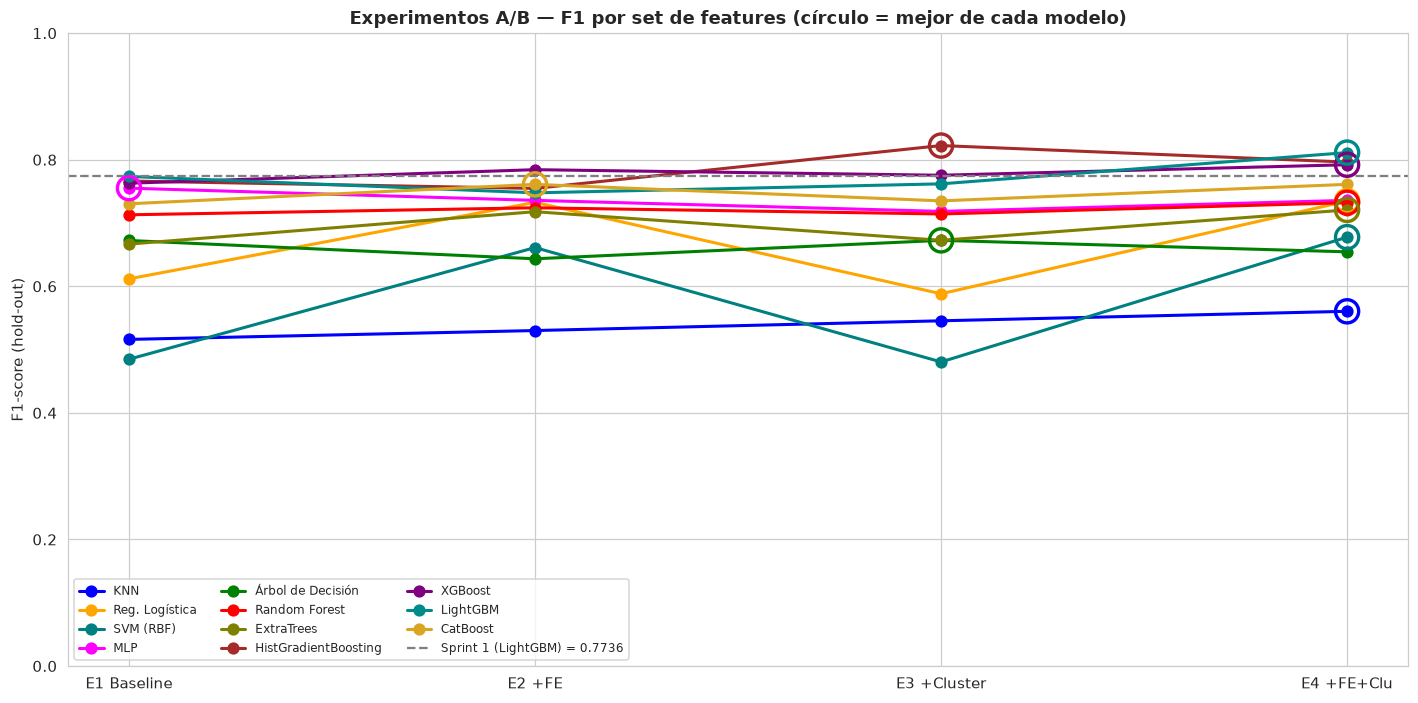

In [11]:
fig, ax = plt.subplots(figsize=(13, 6.5))
x = np.arange(len(EXPERIMENTOS))
for mod in MODELOS:
    ax.plot(x, f1_ab[mod].values, marker='o', lw=2, markersize=7, color=MODEL_COLORS[mod], label=mod)
    xi = EXPERIMENTOS.index(MEJOR_SET[mod])
    ax.scatter([xi], [f1_ab.loc[MEJOR_SET[mod], mod]], s=230, facecolors='none',
               edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.axhline(F1_SPRINT1, ls='--', color='gray',
           label=f'Sprint 1 ({RESUMEN_S1["mejor_modelo"]}) = {F1_SPRINT1:.4f}')
ax.set_xticks(x); ax.set_xticklabels(EXPERIMENTOS)
ax.set_ylabel('F1-score (hold-out)'); ax.set_ylim(0, 1)
ax.set_title('Experimentos A/B — F1 por set de features (círculo = mejor de cada modelo)', fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='lower left')
plt.tight_layout(); plt.savefig('outputs_sprint2/exp_evolucion_f1.png', bbox_inches='tight'); plt.show()

## Optuna

In [12]:
N_TRIALS = 100

f1_mejor_ab = pd.Series({mod: f1_ab.loc[MEJOR_SET[mod], mod] for mod in MODELOS}).sort_values(ascending=False)
TOP_OPTUNA = list(f1_mejor_ab.index)
print(f'Optuna — búsqueda con rangos a-priori ({N_TRIALS} trials/modelo):')
for mod in TOP_OPTUNA:
    print(f'  {mod}: F1={f1_mejor_ab[mod]:.4f} [{MEJOR_SET[mod]}]')

def espacio_params(mod, trial):
    """Rangos elegidos A PRIORI que rodean los defaults de cada librería (no centrados
    en óptimos de CV, para no ajustar al holdout). Ancho amplio para exploración honesta."""
    if mod == 'KNN':
        return {'n_neighbors': trial.suggest_int('n_neighbors', 3, 15, step=2),
                'weights':     trial.suggest_categorical('weights', ['uniform', 'distance']),
                'p':           trial.suggest_int('p', 1, 2)}
    if mod == 'Reg. Logística':
        return {'C':            trial.suggest_float('C', 0.1, 10.0, log=True),
                'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])}
    if mod == 'SVM (RBF)':
        return {'C':            trial.suggest_float('C', 0.5, 10.0, log=True),
                'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])}
    if mod == 'MLP':
        return {'hidden_layer_sizes': trial.suggest_categorical(
                    'hidden_layer_sizes', [(100,), (150,), (200,), (100, 50), (150, 75)]),
                'alpha':              trial.suggest_float('alpha', 1e-5, 1e-3, log=True),
                'learning_rate_init': trial.suggest_float('learning_rate_init', 3e-4, 3e-3, log=True)}
    if mod == 'Árbol de Decisión':
        return {'min_samples_split': trial.suggest_int('min_samples_split', 2, 12),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf',  1, 8),
                'criterion':         trial.suggest_categorical('criterion', ['gini', 'entropy'])}
    if mod == 'Random Forest':
        return {'n_estimators':      trial.suggest_int('n_estimators', 100, 300),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf',  1, 4),
                'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2'])}
    if mod == 'ExtraTrees':
        return {'n_estimators':      trial.suggest_int('n_estimators', 100, 300),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf',  1, 4),
                'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2'])}
    if mod == 'HistGradientBoosting':
        return {'max_iter':          trial.suggest_int('max_iter', 80, 300),
                'learning_rate':     trial.suggest_float('learning_rate', 0.03, 0.2, log=True),
                'max_leaf_nodes':    trial.suggest_int('max_leaf_nodes', 15, 63),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 10, 40),
                'l2_regularization': trial.suggest_float('l2_regularization', 0.0, 1.0)}
    if mod == 'XGBoost':
        return {'n_estimators':    trial.suggest_int('n_estimators',   80,  300),
                'max_depth':       trial.suggest_int('max_depth',       3,    8),
                'learning_rate':   trial.suggest_float('learning_rate', 0.05, 0.3, log=True),
                'subsample':       trial.suggest_float('subsample',     0.7, 1.0),
                'colsample_bytree':trial.suggest_float('colsample_bytree', 0.7, 1.0),
                'min_child_weight':trial.suggest_float('min_child_weight', 1.0, 5.0),
                'gamma':           trial.suggest_float('gamma',          0.0, 0.5),
                'scale_pos_weight':trial.suggest_float('scale_pos_weight', 1.0, 5.0)}
    if mod == 'LightGBM':
        return {'n_estimators':      trial.suggest_int('n_estimators',    80, 300),
                'num_leaves':        trial.suggest_int('num_leaves',       20,  63),
                'learning_rate':     trial.suggest_float('learning_rate',  0.03, 0.2, log=True),
                'subsample':         trial.suggest_float('subsample',      0.7, 1.0),
                'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.7, 1.0),
                'min_child_samples': trial.suggest_int('min_child_samples', 10,  40),
                'reg_lambda':        trial.suggest_float('reg_lambda',      0.0, 1.0)}
    if mod == 'CatBoost':
        return {'iterations':    trial.suggest_int('iterations',     80,  300),
                'depth':         trial.suggest_int('depth',           4,   8),
                'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
                'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg',   1.0,  5.0),
                'subsample':     trial.suggest_float('subsample',     0.7, 1.0)}
    raise ValueError(mod)

def construir_modelo(mod, params):
    """Pipeline (scaler + clasificador)."""
    base = {
        'KNN':                  lambda p: KNeighborsClassifier(**p),
        'Reg. Logística':       lambda p: LogisticRegression(max_iter=2000, random_state=SEED, **p),
        'SVM (RBF)':            lambda p: SVC(kernel='rbf', random_state=SEED, **p),
        'MLP':                  lambda p: MLPClassifier(max_iter=500, random_state=SEED, **p),
        'Árbol de Decisión':    lambda p: DecisionTreeClassifier(random_state=SEED, **p),
        'Random Forest':        lambda p: RandomForestClassifier(random_state=SEED, n_jobs=-1, **p),
        'ExtraTrees':           lambda p: ExtraTreesClassifier(random_state=SEED, n_jobs=-1, **p),
        'HistGradientBoosting': lambda p: HistGradientBoostingClassifier(random_state=SEED, **p),
        'XGBoost':              lambda p: xgb.XGBClassifier(random_state=SEED, eval_metric='logloss',
                                                             tree_method='hist', n_jobs=-1, **p),
        'LightGBM':             lambda p: lgb.LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=-1, **p),
        'CatBoost':             lambda p: CatBoostClassifier(random_seed=SEED, verbose=0, 
                                                             allow_writing_files=False, **p),
    }[mod](params)
    return Pipeline([('sc', StandardScaler()), ('clf', base)])

print('Espacios de búsqueda locales listos.')

Optuna — búsqueda con rangos a-priori (100 trials/modelo):
  HistGradientBoosting: F1=0.8224 [E3 +Cluster]
  LightGBM: F1=0.8113 [E4 +FE+Clu]
  XGBoost: F1=0.7921 [E4 +FE+Clu]
  CatBoost: F1=0.7611 [E2 +FE]
  MLP: F1=0.7551 [E1 Baseline]
  Reg. Logística: F1=0.7347 [E4 +FE+Clu]
  Random Forest: F1=0.7321 [E4 +FE+Clu]
  ExtraTrees: F1=0.7207 [E4 +FE+Clu]
  SVM (RBF): F1=0.6777 [E4 +FE+Clu]
  Árbol de Decisión: F1=0.6726 [E3 +Cluster]
  KNN: F1=0.5605 [E4 +FE+Clu]
Espacios de búsqueda locales listos.


In [13]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def f1_cv(mod, params, Xtr_s):
    """F1 medio en CV 5-fold sobre train; el balanceo del modelo se aplica DENTRO de cada fold."""
    Xv = Xtr_s.values; yv = y_train.values
    f1s = []
    for tr_idx, va_idx in CV.split(Xv, yv):
        Xtr_f, ytr_f = Xv[tr_idx], yv[tr_idx]
        bal = crear_balanceador(BALANCEO_POR_MODELO[mod])
        if bal is not None:
            Xtr_f, ytr_f = bal.fit_resample(Xtr_f, ytr_f)
        clf = construir_modelo(mod, params)
        clf.fit(Xtr_f, ytr_f)
        f1s.append(f1_score(yv[va_idx], clf.predict(Xv[va_idx])))
    return float(np.mean(f1s))

studies, best_params = {}, {}
for mod in TOP_OPTUNA:
    Xtr_s = SETS[MEJOR_SET[mod]][0]
    t0 = time.time()
    st = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
    st.optimize(lambda tr: f1_cv(mod, espacio_params(mod, tr), Xtr_s),
                n_trials=N_TRIALS, show_progress_bar=False)
    studies[mod] = st
    best_params[mod] = dict(st.best_params)
    print(f'{mod} [{MEJOR_SET[mod]}] → mejor F1 CV = {st.best_value:.4f} '
          f'({time.time()-t0:.0f}s, {len(st.trials)} trials)')
    print('  params:', st.best_params)
with open('outputs_sprint2/optuna_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2, ensure_ascii=False)

HistGradientBoosting [E3 +Cluster] → mejor F1 CV = 0.7387 (358s, 100 trials)
  params: {'max_iter': 97, 'learning_rate': 0.13582560519962192, 'max_leaf_nodes': 29, 'min_samples_leaf': 38, 'l2_regularization': 0.8638428634918951}
LightGBM [E4 +FE+Clu] → mejor F1 CV = 0.7311 (458s, 100 trials)
  params: {'n_estimators': 181, 'num_leaves': 63, 'learning_rate': 0.12775544212230172, 'subsample': 0.8205011525080843, 'colsample_bytree': 0.737753487748497, 'min_child_samples': 35, 'reg_lambda': 0.10679607715089304}
XGBoost [E4 +FE+Clu] → mejor F1 CV = 0.7449 (233s, 100 trials)
  params: {'n_estimators': 144, 'max_depth': 4, 'learning_rate': 0.18074574214927297, 'subsample': 0.783731120859725, 'colsample_bytree': 0.7481186240051169, 'min_child_weight': 1.7266306077334548, 'gamma': 0.1647213011362094, 'scale_pos_weight': 4.682479995644405}
CatBoost [E2 +FE] → mejor F1 CV = 0.7411 (1695s, 100 trials)
  params: {'iterations': 226, 'depth': 6, 'learning_rate': 0.036506995474255566, 'l2_leaf_reg': 1

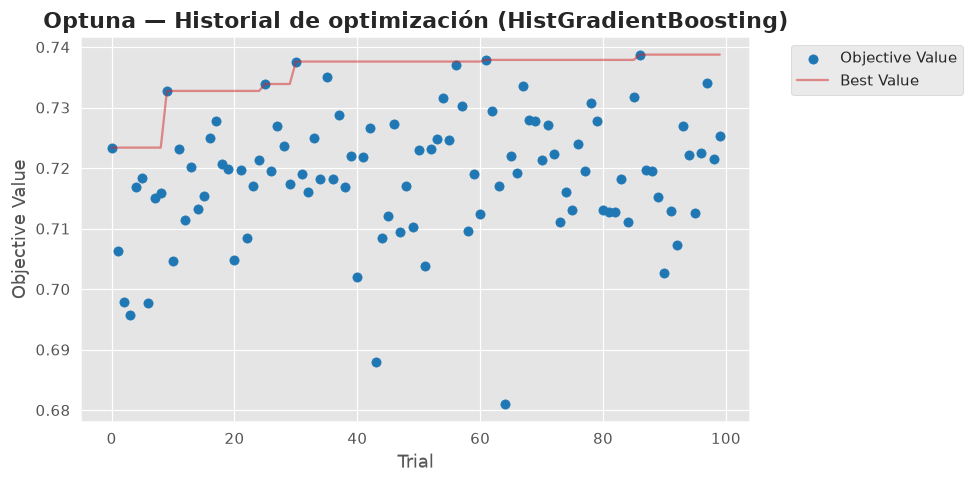

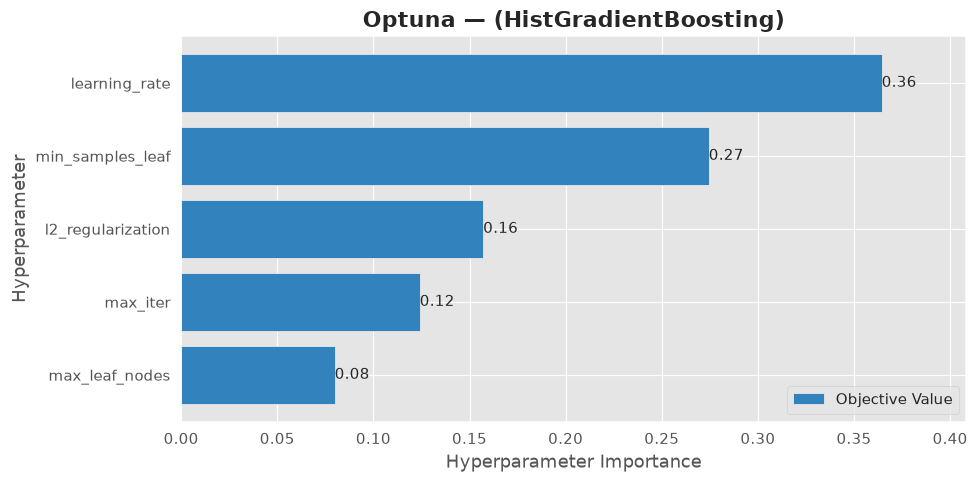

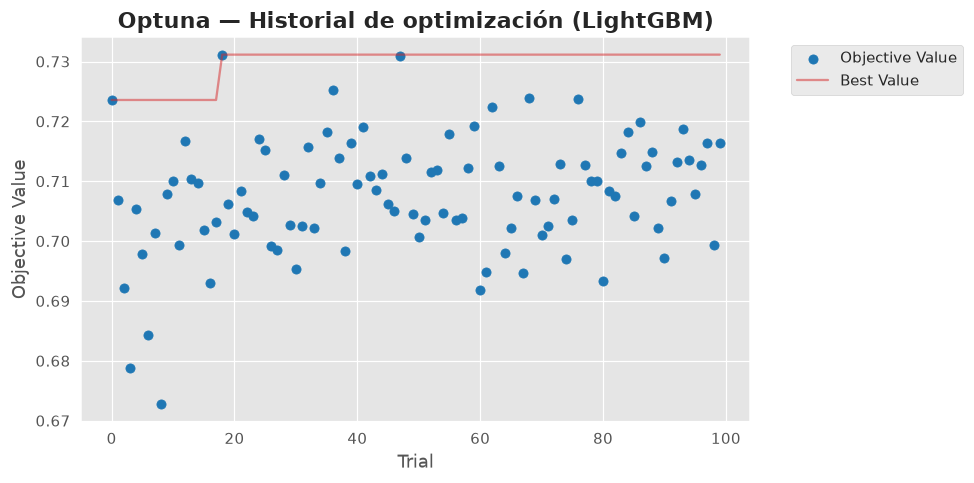

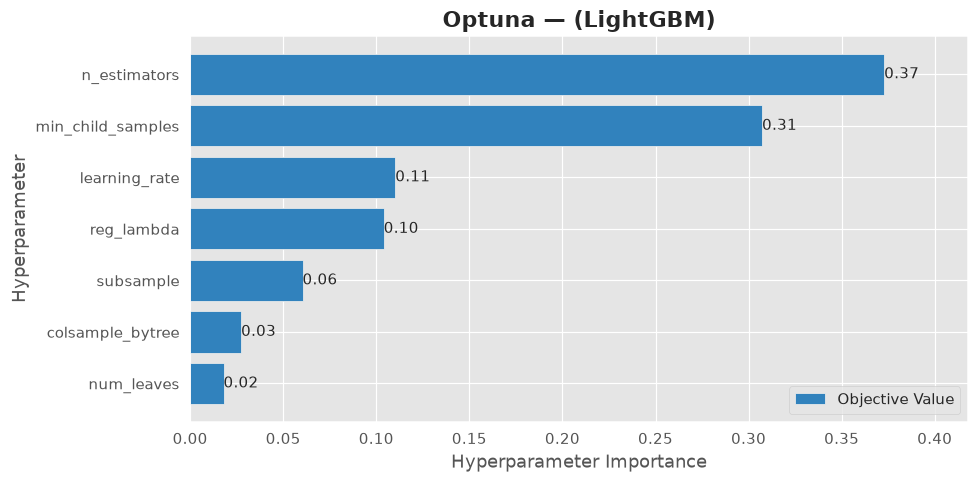

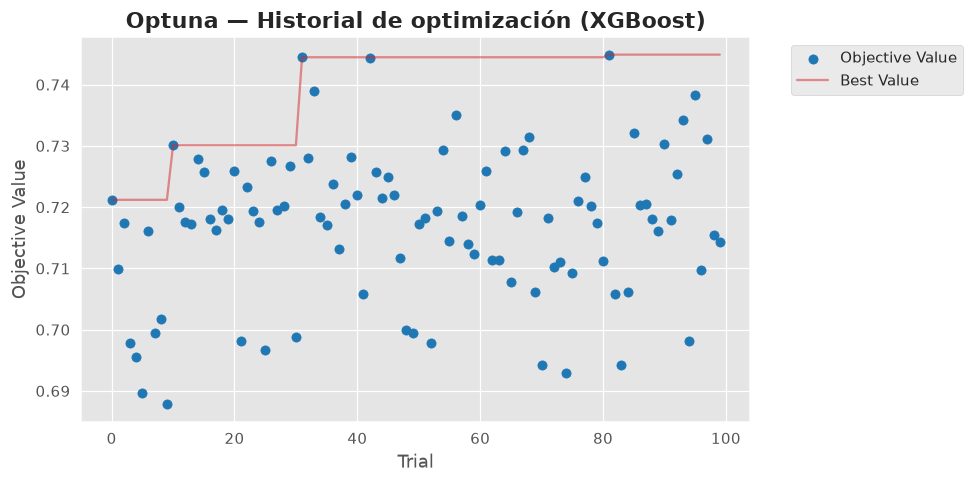

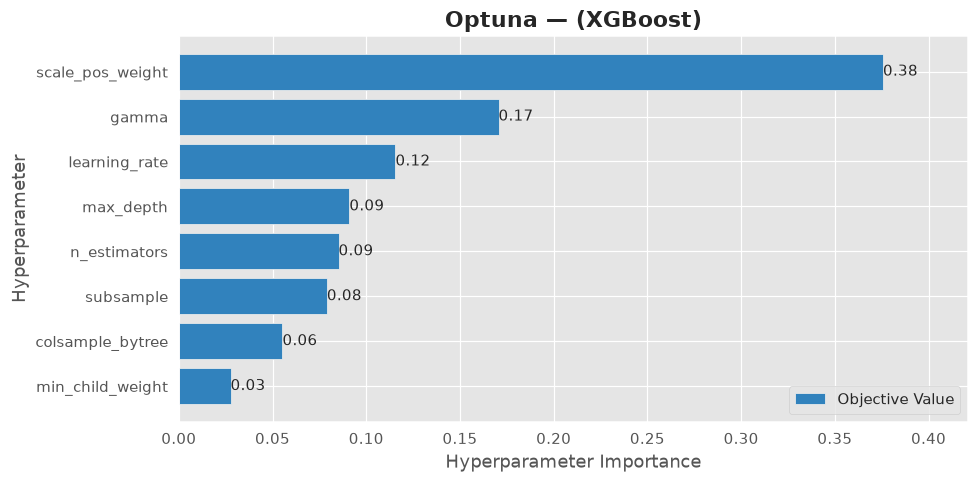

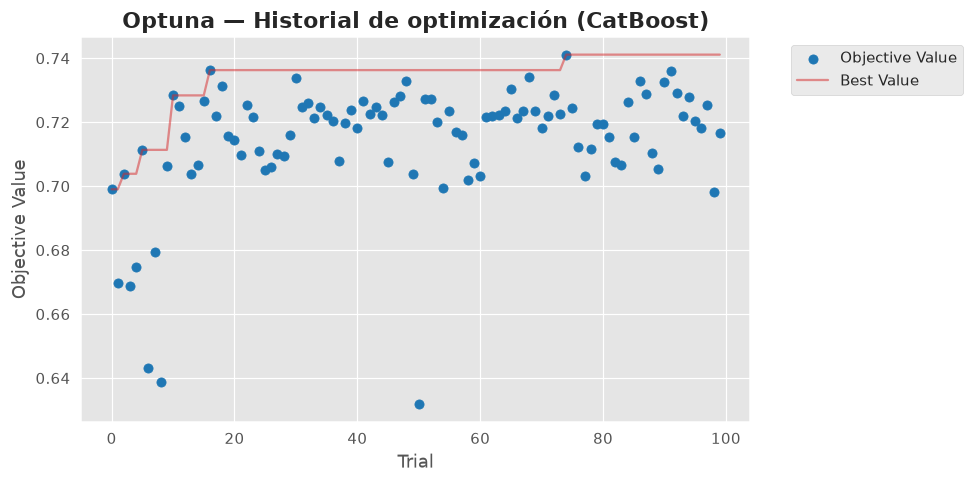

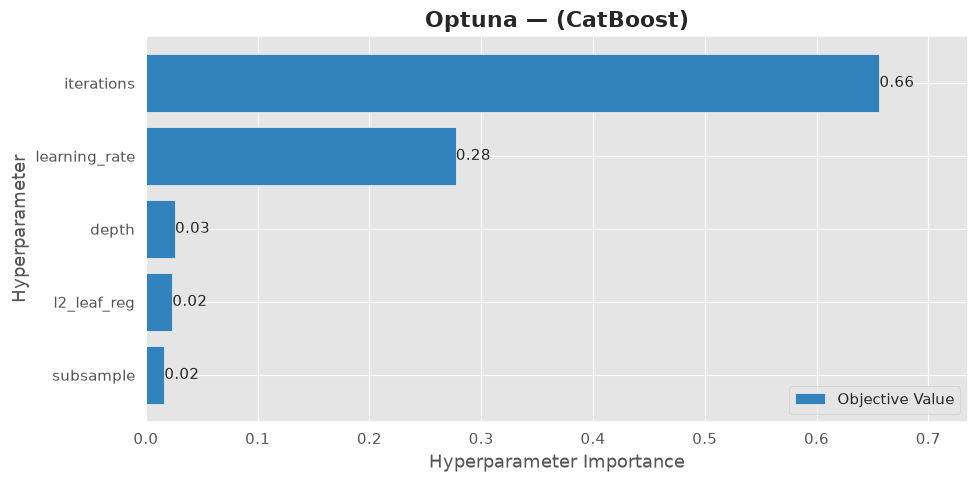

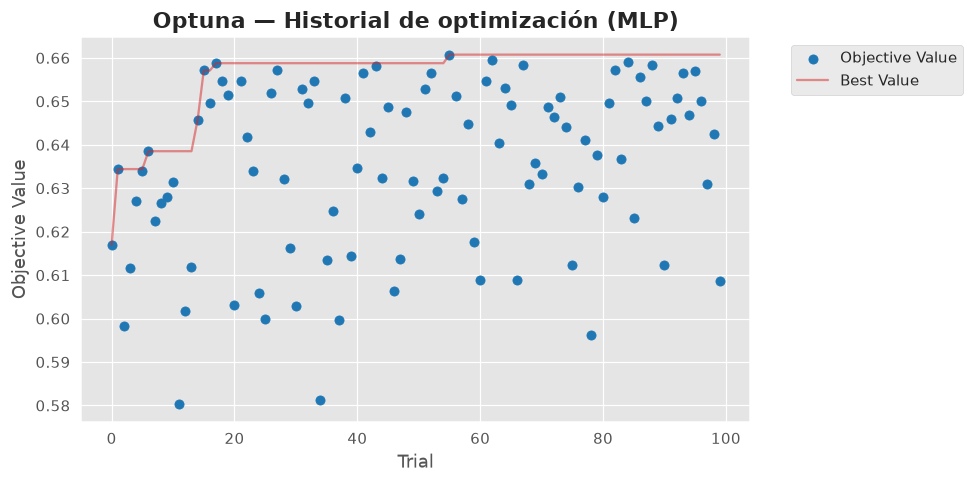

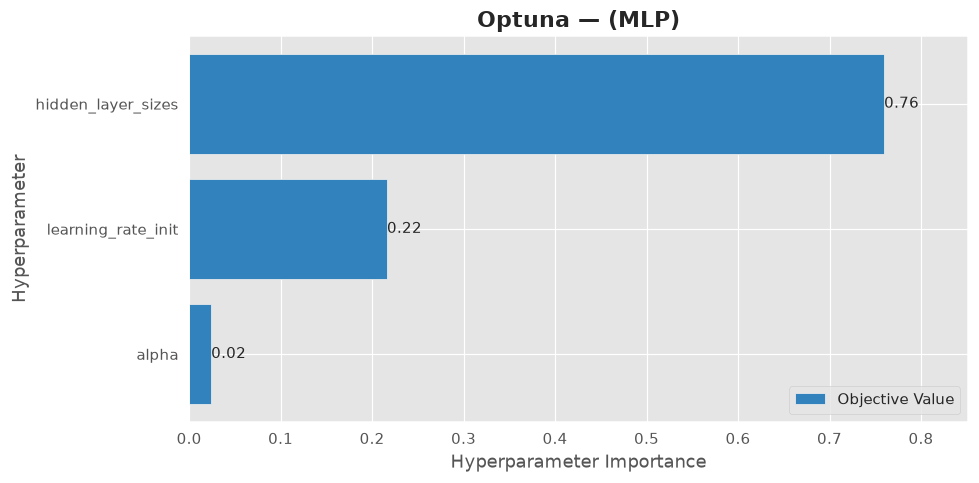

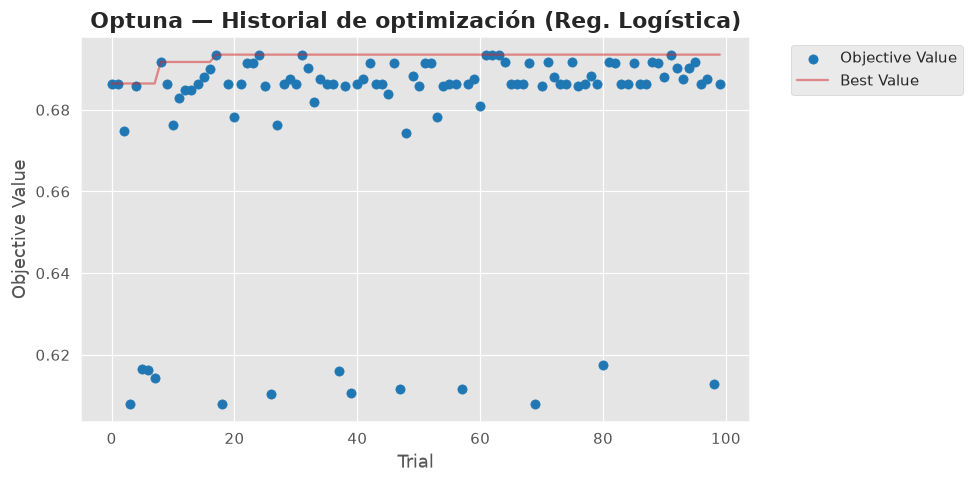

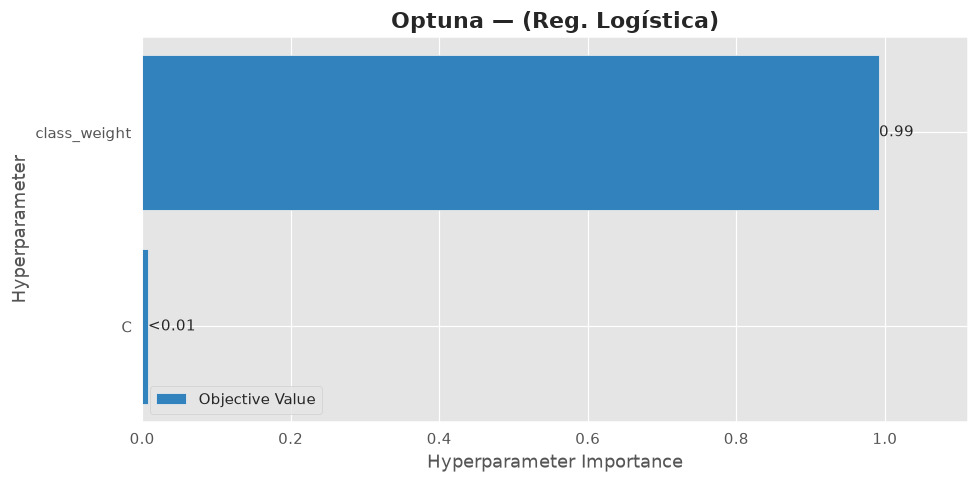

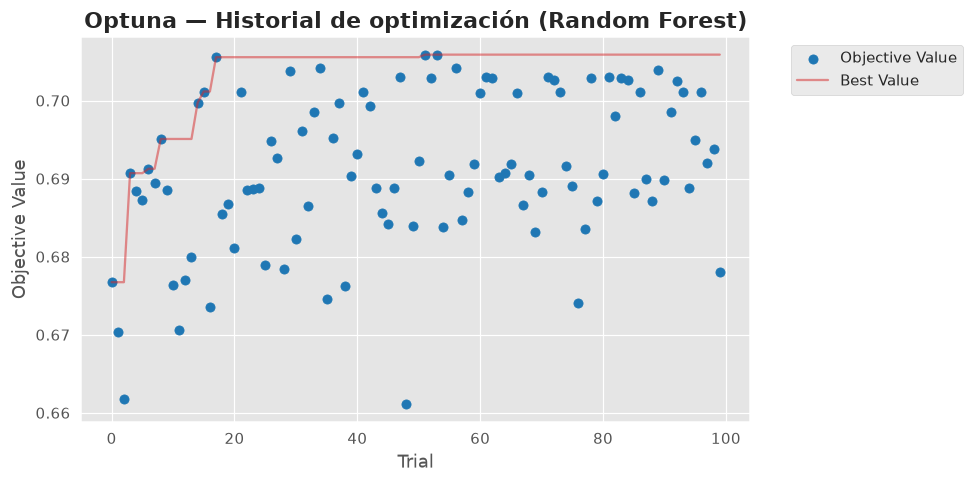

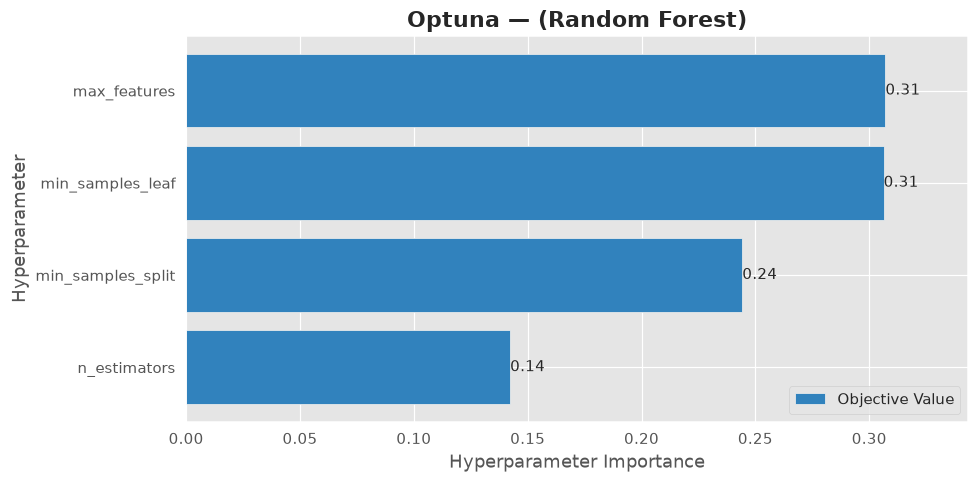

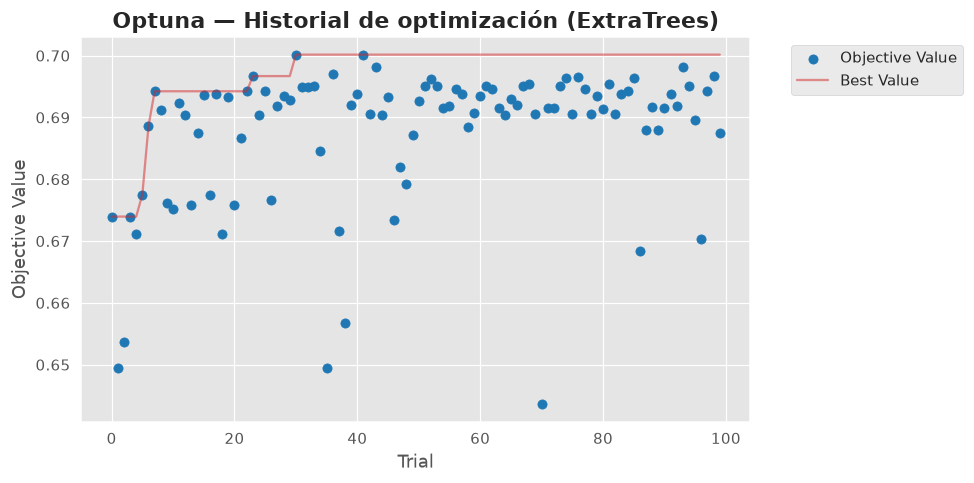

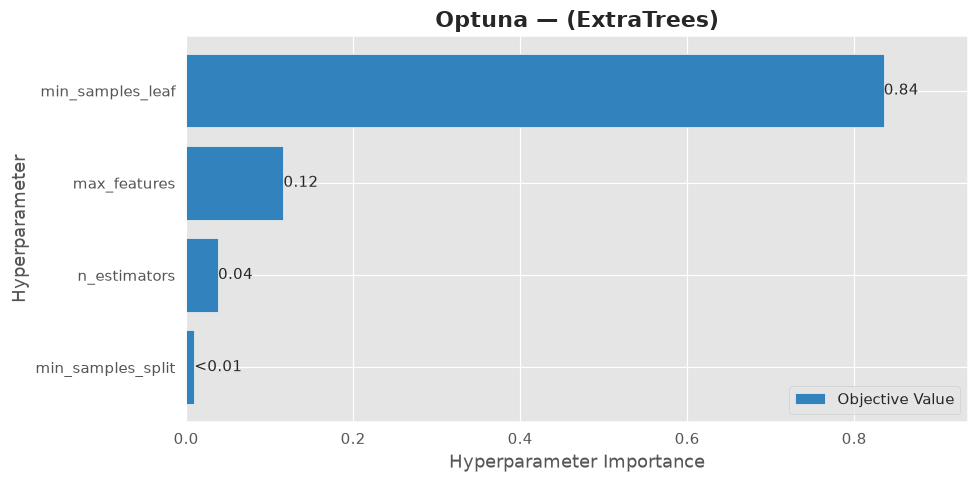

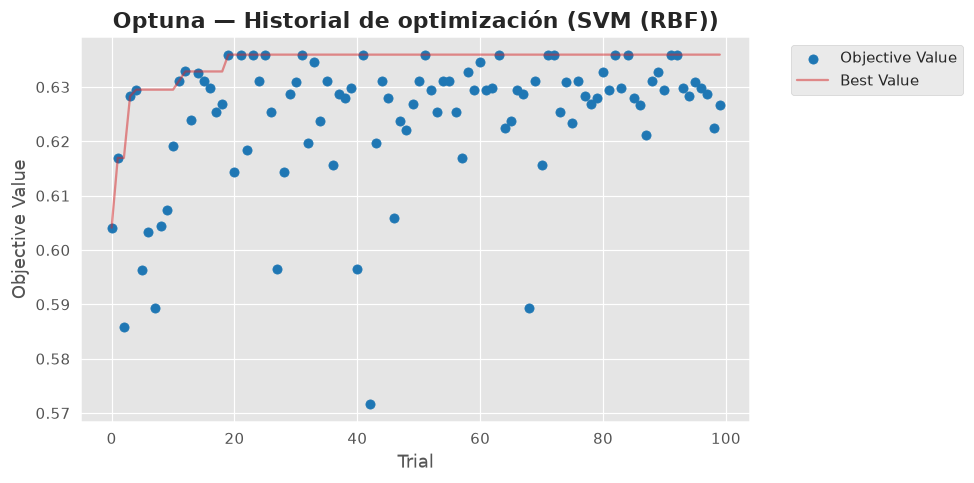

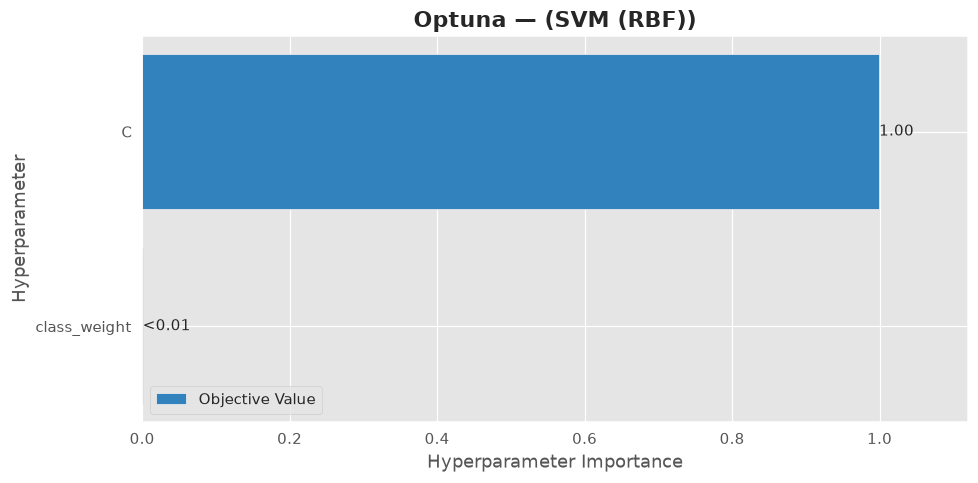

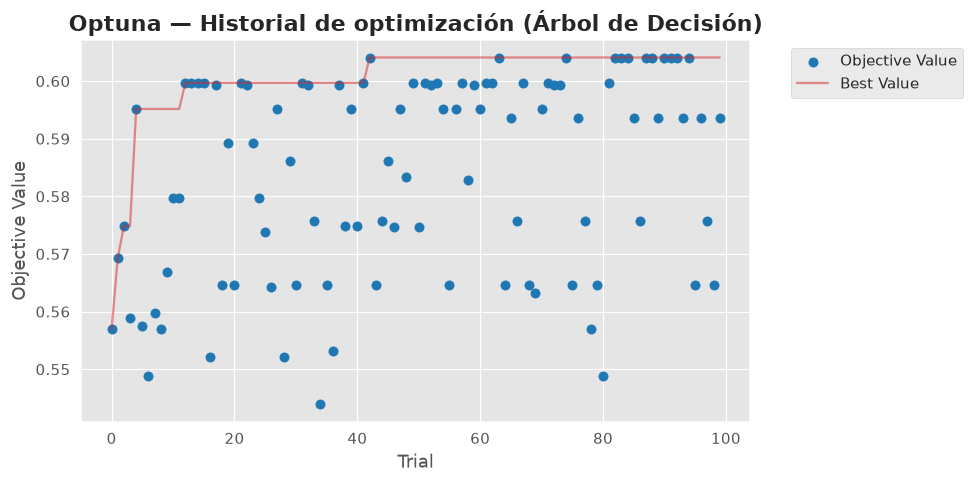

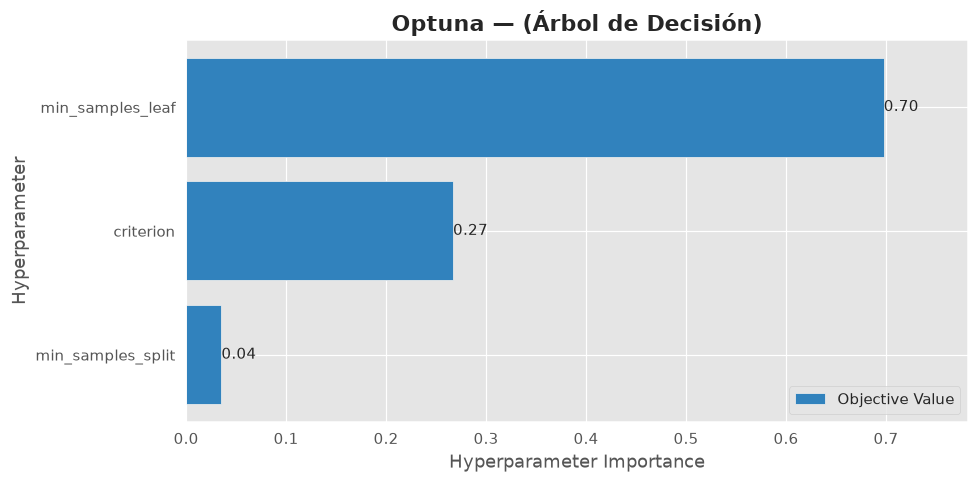

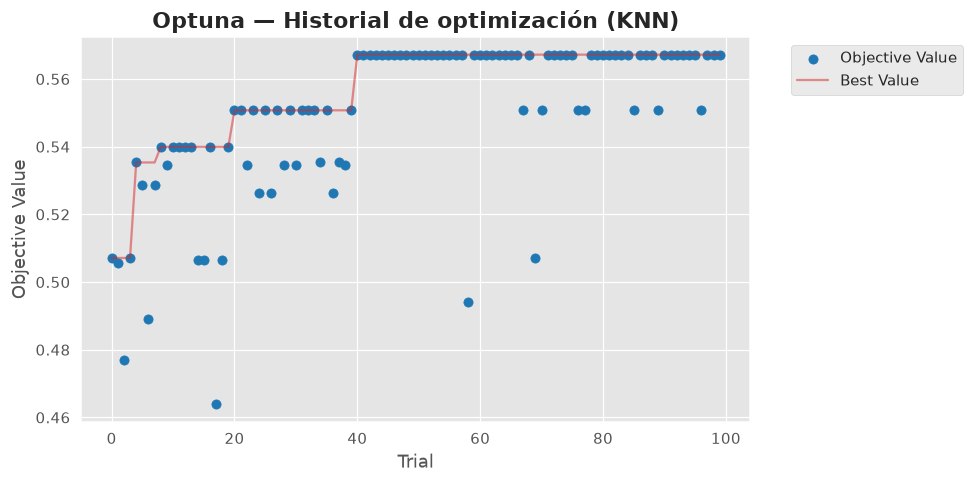

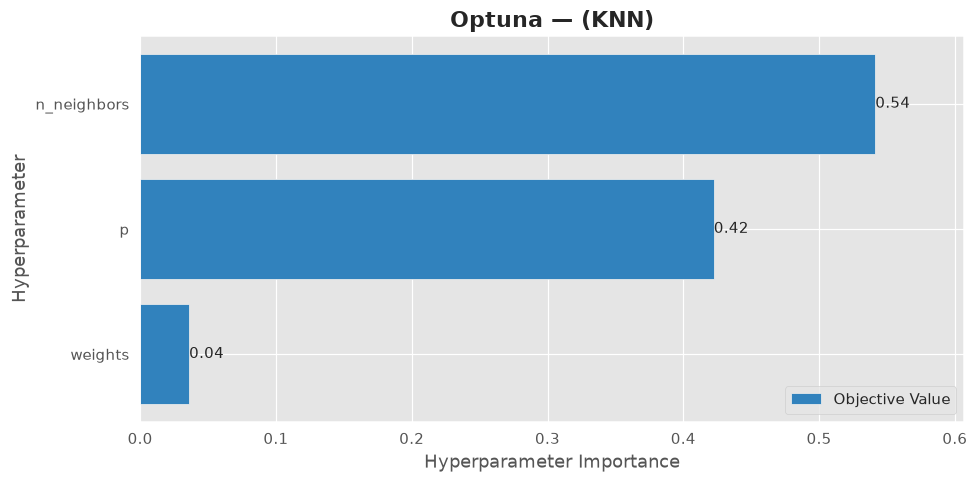

In [21]:
import warnings as _w
from optuna.exceptions import ExperimentalWarning
_w.filterwarnings('ignore', category=ExperimentalWarning)

from optuna.visualization.matplotlib import (plot_optimization_history,
                                              plot_param_importances)
for mod in TOP_OPTUNA:
    tag = mod.replace(' ', '').replace('.', '').replace('(', '').replace(')', '')
    ax = plot_optimization_history(studies[mod])
    ax.set_title(f'Optuna — Historial de optimización ({mod})', fontweight='bold')
    plt.gcf().set_size_inches(9, 4.5); plt.tight_layout()
    plt.savefig(f'outputs_sprint2/optuna_historial_{tag}.png', bbox_inches='tight'); plt.show()

    ax = plot_param_importances(studies[mod])
    ax.set_title('', loc='left')
    ax.set_title(f'Optuna — ({mod})', fontweight='bold')
    plt.gcf().set_size_inches(9, 4.5); plt.tight_layout()
    plt.savefig(f'outputs_sprint2/optuna_importancia_{tag}.png', bbox_inches='tight'); plt.show()

In [15]:
import warnings as _w
_w.filterwarnings('ignore', message='X does not have valid feature names')

res_optuna = {}
for mod in TOP_OPTUNA:
    Xtr_s, Xte_s = SETS[MEJOR_SET[mod]]
    clf = construir_modelo(mod, best_params[mod])
    res_optuna[mod] = entrenar_evaluar(mod, Xtr_s, y_train, Xte_s, y_test, clf=clf)
    print(f"{mod} + Optuna [{MEJOR_SET[mod]}] → F1 hold-out = {res_optuna[mod]['F1']:.4f} "
          f"(A/B era {f1_ab.loc[MEJOR_SET[mod], mod]:.4f})")

HistGradientBoosting + Optuna [E3 +Cluster] → F1 hold-out = 0.7679 (A/B era 0.8224)
LightGBM + Optuna [E4 +FE+Clu] → F1 hold-out = 0.7647 (A/B era 0.8113)
XGBoost + Optuna [E4 +FE+Clu] → F1 hold-out = 0.7931 (A/B era 0.7921)
CatBoost + Optuna [E2 +FE] → F1 hold-out = 0.7395 (A/B era 0.7611)
MLP + Optuna [E1 Baseline] → F1 hold-out = 0.7033 (A/B era 0.7551)
Reg. Logística + Optuna [E4 +FE+Clu] → F1 hold-out = 0.7273 (A/B era 0.7347)
Random Forest + Optuna [E4 +FE+Clu] → F1 hold-out = 0.7434 (A/B era 0.7321)
ExtraTrees + Optuna [E4 +FE+Clu] → F1 hold-out = 0.7257 (A/B era 0.7207)
SVM (RBF) + Optuna [E4 +FE+Clu] → F1 hold-out = 0.6549 (A/B era 0.6777)
Árbol de Decisión + Optuna [E3 +Cluster] → F1 hold-out = 0.6829 (A/B era 0.6726)
KNN + Optuna [E4 +FE+Clu] → F1 hold-out = 0.5797 (A/B era 0.5605)


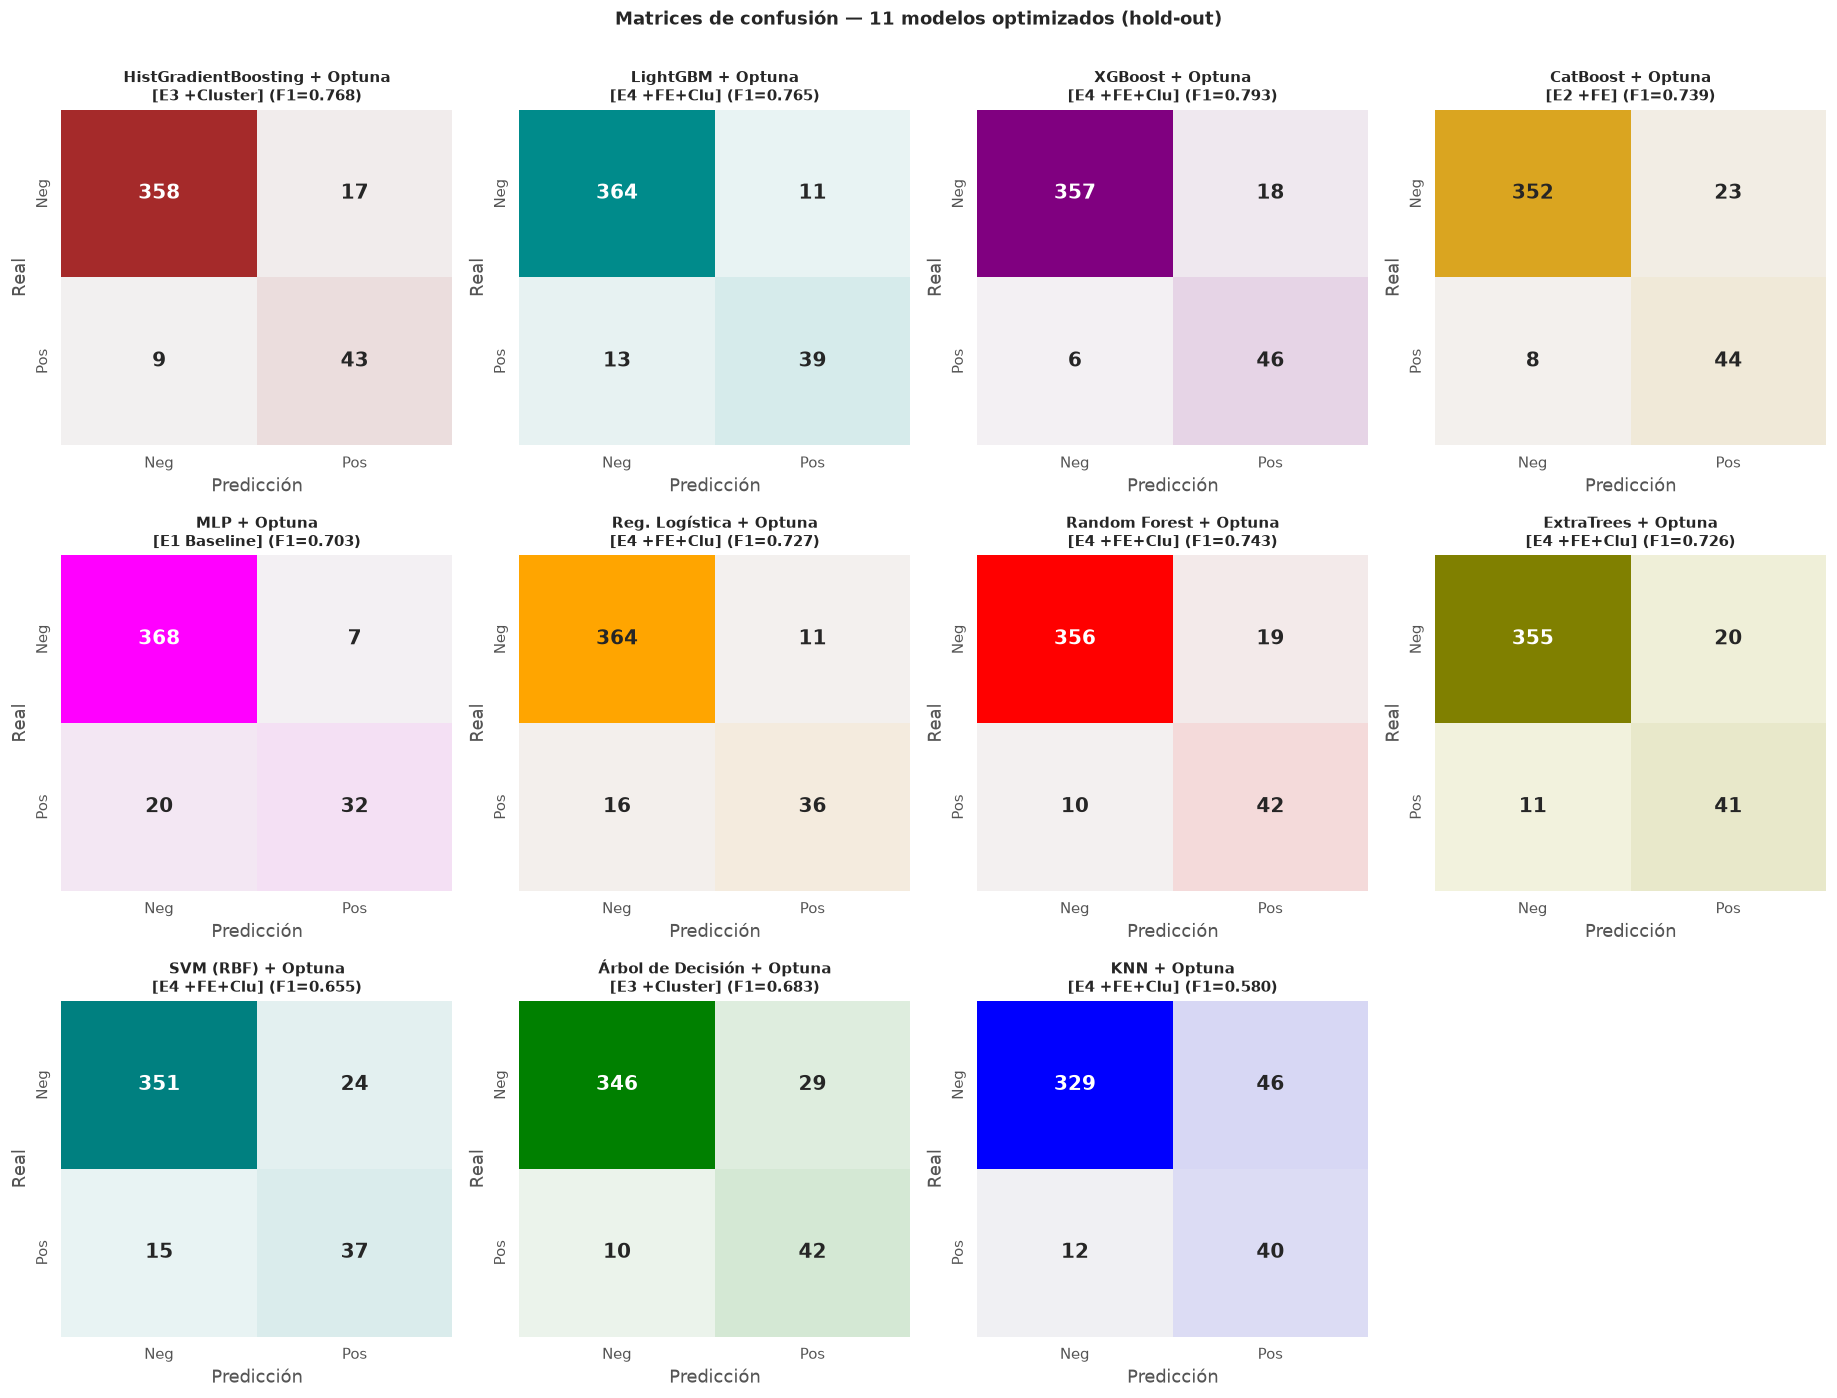

In [16]:
n_mods = len(TOP_OPTUNA)
n_cols = 4
n_rows = int(np.ceil(n_mods / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4.2 * n_rows))
axes = np.atleast_1d(axes).ravel()
for ax, mod in zip(axes, TOP_OPTUNA):
    r = res_optuna[mod]
    cm = confusion_matrix(y_test, r['_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax,
                cmap=sns.light_palette(MODEL_COLORS[mod], as_cmap=True),
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
                annot_kws={'size': 13, 'fontweight': 'bold'})
    ax.set_title(f'{mod} + Optuna\n[{MEJOR_SET[mod]}] (F1={r["F1"]:.3f})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
for ax in axes[n_mods:]:
    ax.axis('off')
plt.suptitle('Matrices de confusión — 11 modelos optimizados (hold-out)', fontweight='bold', y=1.005)
plt.tight_layout(); plt.savefig('outputs_sprint2/optuna_matrices_confusion.png', bbox_inches='tight'); plt.show()

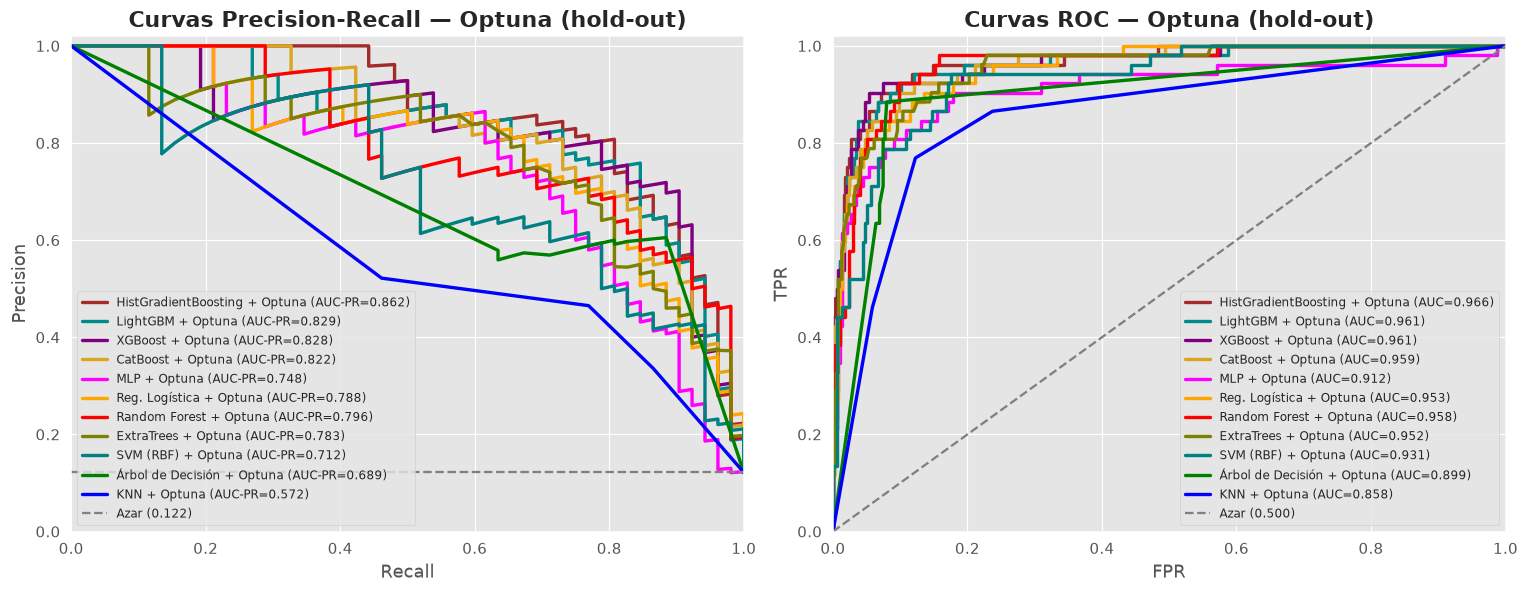

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for mod in TOP_OPTUNA:
    prob = res_optuna[mod]['_prob']
    p, r, _ = precision_recall_curve(y_test, prob)
    axes[0].plot(r, p, color=MODEL_COLORS[mod], lw=2.2,
                 label=f'{mod} + Optuna (AUC-PR={auc(r, p):.3f})')
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[1].plot(fpr, tpr, color=MODEL_COLORS[mod], lw=2.2,
                 label=f'{mod} + Optuna (AUC={roc_auc_score(y_test, prob):.3f})')
axes[0].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].set_title('Curvas Precision-Recall — Optuna (hold-out)', fontweight='bold'); axes[0].legend(fontsize=8)
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Azar (0.500)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curvas ROC — Optuna (hold-out)', fontweight='bold'); axes[1].legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint2/optuna_curvas_pr_roc.png', bbox_inches='tight'); plt.show()

## Tabla comparativa

In [18]:
etapas_f1 = []
mejor_cfg_final = {}
for mod in MODELOS:
    f1_e1 = f1_ab.loc['E1 Baseline', mod]
    f1_ab_best = f1_ab.loc[MEJOR_SET[mod], mod]
    f1_opt = res_optuna[mod]['F1'] if mod in res_optuna else np.nan
    if mod in res_optuna and f1_opt > f1_ab_best:
        mejor_cfg_final[mod] = '+ Optuna'
        f1_final_mod = f1_opt
    else:
        mejor_cfg_final[mod] = 'Mejor experimento'
        f1_final_mod = f1_ab_best
    etapas_f1.append({'Modelo': mod, 'E1 Baseline': round(f1_e1, 4),
                      'Mejor experimento': round(f1_ab_best, 4),
                      'Set': MEJOR_SET[mod],
                      '+ Optuna': round(f1_opt, 4) if mod in res_optuna else '—',
                      'Mejor F1 final': round(f1_final_mod, 4),
                      'Config final': mejor_cfg_final[mod],
                      'Δ vs E1': round(f1_final_mod - f1_e1, 4)})
tabla_f1 = pd.DataFrame(etapas_f1).set_index('Modelo')
tabla_f1.to_csv('outputs_sprint2/tabla_comparativa_f1.csv')
print('Antes/después — F1 (hold-out):')
display(tabla_f1)

Antes/después — F1 (hold-out):


,E1 Baseline,Mejor experimento,Set,+ Optuna,Mejor F1 final,Config final,Δ vs E1
Modelo,,,,,,,
KNN,0.5161,0.5605,E4 +FE+Clu,0.5797,0.5797,+ Optuna,0.0636
Reg. Logística,0.6118,0.7347,E4 +FE+Clu,0.7273,0.7347,Mejor experimento,0.1229
SVM (RBF),0.4848,0.6777,E4 +FE+Clu,0.6549,0.6777,Mejor experimento,0.1929
MLP,0.7551,0.7551,E1 Baseline,0.7033,0.7551,Mejor experimento,0.0000
Árbol de Decisión,0.6724,0.6726,E3 +Cluster,0.6829,0.6829,+ Optuna,0.0105
Random Forest,0.7130,0.7321,E4 +FE+Clu,0.7434,0.7434,+ Optuna,0.0304
ExtraTrees,0.6667,0.7207,E4 +FE+Clu,0.7257,0.7257,+ Optuna,0.0590
HistGradientBoosting,0.7664,0.8224,E3 +Cluster,0.7679,0.8224,Mejor experimento,0.0560
XGBoost,0.7629,0.7921,E4 +FE+Clu,0.7931,0.7931,+ Optuna,0.0302


In [19]:
def resultado_final(mod):
    if mejor_cfg_final[mod] == '+ Optuna':
        return res_optuna[mod]
    return res_ab[(MEJOR_SET[mod], mod)]

METRICAS = ['F1', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC']
filas = []
for mod in MODELOS:
    antes = res_ab[('E1 Baseline', mod)]
    desp = resultado_final(mod)
    for met in METRICAS:
        filas.append({'Modelo': mod,
                      'Config final': f'{mejor_cfg_final[mod]} [{MEJOR_SET[mod]}]',
                      'Métrica': met,
                      'Antes (E1)': round(antes[met], 4),
                      'Después': round(desp[met], 4),
                      'Δ': round(desp[met] - antes[met], 4)})
tabla_todas = pd.DataFrame(filas)
tabla_todas.to_csv('outputs_sprint2/tabla_comparativa_todas.csv', index=False)
display(tabla_todas.pivot_table(index=['Modelo', 'Config final'], columns='Métrica',
        values=['Antes (E1)', 'Después', 'Δ']).round(4))

Antes (E1)           \
Métrica                                                 AUC-ROC Accuracy   
Modelo               Config final                                          
CatBoost             Mejor experimento [E2 +FE]          0.9570   0.9274   
ExtraTrees           + Optuna [E4 +FE+Clu]               0.9386   0.9063   
HistGradientBoosting Mejor experimento [E3 +Cluster]     0.9705   0.9415   
KNN                  + Optuna [E4 +FE+Clu]               0.8751   0.8244   
LightGBM             Mejor experimento [E4 +FE+Clu]      0.9662   0.9438   
MLP                  Mejor experimento [E1 Baseline]     0.9395   0.9438   
Random Forest        + Optuna [E4 +FE+Clu]               0.9506   0.9227   
Reg. Logística       Mejor experimento [E4 +FE+Clu]      0.9369   0.9227   
SVM (RBF)            Mejor experimento [E4 +FE+Clu]      0.8914   0.8009   
XGBoost              + Optuna [E4 +FE+Clu]               0.9648   0.9461   
Árbol de Decisión    + Optuna [E3 +Cluster]              0.8417   0.9110   

                                                                        \
Métrica                                                   F1 Precision   
Modelo               Config final                                        
CatBoost             Mejor experimento [E2 +FE]       0.7304    0.6667   
ExtraTrees           + Optuna [E4 +FE+Clu]            0.6667    0.5882   
HistGradientBoosting Mejor experimento [E3 +Cluster]  0.7664    0.7455   
KNN                  + Optuna [E4 +FE+Clu]            0.5161    0.3883   
LightGBM             Mejor experimento [E4 +FE+Clu]   0.7736    0.7593   
MLP                  Mejor experimento [E1 Baseline]  0.7551    0.8043   
Random Forest        + Optuna [E4 +FE+Clu]            0.7130    0.6508   
Reg. Logística       Mejor experimento [E4 +FE+Clu]   0.6118    0.7879   
SVM (RBF)            Mejor experimento [E4 +FE+Clu]   0.4848    0.3540   
XGBoost              + Optuna [E4 +FE+Clu]            0.7629    0.8222   
Árbol de Decisión    + Optuna [E3 +Cluster]           0.6724    0.6094   

                                                             Después           \
Métrica                                               Recall AUC-ROC Accuracy   
Modelo               Config final                                               
CatBoost             Mejor experimento [E2 +FE]       0.8077  0.9597   0.9368   
ExtraTrees           + Optuna [E4 +FE+Clu]            0.7692  0.9524   0.9274   
HistGradientBoosting Mejor experimento [E3 +Cluster]  0.7885  0.9721   0.9555   
KNN                  + Optuna [E4 +FE+Clu]            0.7692  0.8580   0.8642   
LightGBM             Mejor experimento [E4 +FE+Clu]   0.7885  0.9696   0.9532   
MLP                  Mejor experimento [E1 Baseline]  0.7115  0.9395   0.9438   
Random Forest        + Optuna [E4 +FE+Clu]            0.7885  0.9583   0.9321   
Reg. Logística       Mejor experimento [E4 +FE+Clu]   0.5000  0.9621   0.9391   
SVM (RBF)            Mejor experimento [E4 +FE+Clu]   0.7692  0.9407   0.9087   
XGBoost              + Optuna [E4 +FE+Clu]            0.7115  0.9613   0.9438   
Árbol de Decisión    + Optuna [E3 +Cluster]           0.7500  0.8987   0.9087   

                                                                        \
Métrica                                                   F1 Precision   
Modelo               Config final                                        
CatBoost             Mejor experimento [E2 +FE]       0.7611    0.7049   
ExtraTrees           + Optuna [E4 +FE+Clu]            0.7257    0.6721   
HistGradientBoosting Mejor experimento [E3 +Cluster]  0.8224    0.8000   
KNN                  + Optuna [E4 +FE+Clu]            0.5797    0.4651   
LightGBM             Mejor experimento [E4 +FE+Clu]   0.8113    0.7963   
MLP                  Mejor experimento [E1 Baseline]  0.7551    0.8043   
Random Forest        + Optuna [E4 +FE+Clu]            0.7434    0.6885   
Reg. Logística       Mejor experimento [E4 +FE+Clu]   0.7347    0.7826   
SV

## Resumen

In [20]:
mejor_modelo_global = max(MODELOS, key=lambda m: resultado_final(m)['F1'])
res_ganador = resultado_final(mejor_modelo_global)
Xtr_g, Xte_g = SETS[MEJOR_SET[mejor_modelo_global]]

# Importancias del ganador (nativa → |coef| → permutación, según disponga el modelo)
clf_g = res_ganador['_clf'].named_steps['clf']
if hasattr(clf_g, 'feature_importances_'):
    imp_g = pd.Series(np.asarray(clf_g.feature_importances_, dtype=float), index=Xtr_g.columns)
elif hasattr(clf_g, 'coef_'):
    imp_g = pd.Series(np.abs(clf_g.coef_).ravel(), index=Xtr_g.columns)
else:
    r_perm = permutation_importance(res_ganador['_clf'], Xte_g, y_test, scoring='f1',
                                    n_repeats=5, random_state=SEED, n_jobs=-1)
    imp_g = pd.Series(np.clip(r_perm.importances_mean, 0, None), index=Xtr_g.columns)
importancias = imp_g.sort_values(ascending=False)
importancias.to_csv('outputs_sprint2/mejor_modelo_importancias.csv', header=['importancia'])

resumen = {'mejor_modelo': mejor_modelo_global,
           'mejor_set': MEJOR_SET[mejor_modelo_global],
           'config_final': mejor_cfg_final[mejor_modelo_global],
           'metodo_balanceo': BALANCEO_POR_MODELO[mejor_modelo_global],
           'f1_final': round(res_ganador['F1'], 4),
           'f1_sprint0': F1_SPRINT0,
           'f1_sprint1': F1_SPRINT1,
           'mejora_vs_sprint0': round(res_ganador['F1'] - F1_SPRINT0, 4),
           'mejora_vs_sprint1': round(res_ganador['F1'] - F1_SPRINT1, 4),
           'metricas_finales': {m: round(res_ganador[m], 4) for m in METRICAS},
           'best_params_optuna': best_params.get(mejor_modelo_global, {}),
           'f1_por_modelo': {m: round(resultado_final(m)['F1'], 4) for m in MODELOS},
           'mejor_set_por_modelo': MEJOR_SET,
           'balanceo_por_modelo': BALANCEO_POR_MODELO,
           'top_optuna': TOP_OPTUNA,
           'ratios_seleccionados': {k: list(v) for k, v in RATIOS.items()},
           'features_set_ganador': list(Xtr_g.columns),
           'features_clustering': FEATURES_CLU,
           'elementos_economicos_excluidos_fe': ELEM_ECONOMICOS,
           'cols_espacio_clustering_base': COLS_CLU_BASE,
           'cols_espacio_clustering_fe': COLS_CLU_FE}
with open('outputs_sprint2/resumen_sprint2.json', 'w') as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)

print('════════════ RESUMEN SPRINT 2 ════════════')
print(f'Resultado de FE y clustering ({len(MODELOS)} modelos)')
for mod in MODELOS:
    delta = f1_ab.loc[MEJOR_SET[mod], mod] - f1_ab.loc['E1 Baseline', mod]
    extra = f" | Optuna={res_optuna[mod]['F1']:.4f}" if mod in res_optuna else ''
    print(f'  {mod}: E1={f1_ab.loc["E1 Baseline", mod]:.4f} → {MEJOR_SET[mod]}='
          f'{f1_ab.loc[MEJOR_SET[mod], mod]:.4f} (Δ={delta:+.4f}){extra}')
print(f'\nMejor modelo')
print(f'  GANADOR: {mejor_modelo_global} ({mejor_cfg_final[mejor_modelo_global]}, '
      f'{MEJOR_SET[mejor_modelo_global]}, balanceo={BALANCEO_POR_MODELO[mejor_modelo_global]}) '
      f'→ F1 = {res_ganador["F1"]:.4f}')
print(f'  Evolución del proyecto:')
print(f'    Sprint 0 = {F1_SPRINT0:.4f} (baseline, {RESUMEN_S0["mejor_modelo"]})')
print(f'    Sprint 1 = {F1_SPRINT1:.4f} ({F1_SPRINT1-F1_SPRINT0:+.4f}) — {RESUMEN_S1["mejor_modelo"]} + {RESUMEN_S1["metodo_balanceo"]}')
print(f'    Sprint 2 = {res_ganador["F1"]:.4f} ({res_ganador["F1"]-F1_SPRINT1:+.4f}) — {mejor_modelo_global} + {BALANCEO_POR_MODELO[mejor_modelo_global]} '
      f'+ {mejor_cfg_final[mejor_modelo_global]} + {MEJOR_SET[mejor_modelo_global]}')
print('\nTop-15 features más importantes del ganador:')
display(importancias.head(15).round(4).to_frame('importancia'))
print('Siguiente paso (Sprint 3): SHAP del ganador + clustering en espacio SHAP + calibración y umbral.')

════════════ RESUMEN SPRINT 2 ════════════
Resultado de FE y clustering (11 modelos)
  KNN: E1=0.5161 → E4 +FE+Clu=0.5605 (Δ=+0.0444) | Optuna=0.5797
  Reg. Logística: E1=0.6118 → E4 +FE+Clu=0.7347 (Δ=+0.1229) | Optuna=0.7273
  SVM (RBF): E1=0.4848 → E4 +FE+Clu=0.6777 (Δ=+0.1929) | Optuna=0.6549
  MLP: E1=0.7551 → E1 Baseline=0.7551 (Δ=+0.0000) | Optuna=0.7033
  Árbol de Decisión: E1=0.6724 → E3 +Cluster=0.6726 (Δ=+0.0002) | Optuna=0.6829
  Random Forest: E1=0.7130 → E4 +FE+Clu=0.7321 (Δ=+0.0191) | Optuna=0.7434
  ExtraTrees: E1=0.6667 → E4 +FE+Clu=0.7207 (Δ=+0.0540) | Optuna=0.7257
  HistGradientBoosting: E1=0.7664 → E3 +Cluster=0.8224 (Δ=+0.0560) | Optuna=0.7679
  XGBoost: E1=0.7629 → E4 +FE+Clu=0.7921 (Δ=+0.0292) | Optuna=0.7931
  LightGBM: E1=0.7736 → E4 +FE+Clu=0.8113 (Δ=+0.0377) | Optuna=0.7647
  CatBoost: E1=0.7304 → E2 +FE=0.7611 (Δ=+0.0307) | Optuna=0.7395

Mejor modelo
  GANADOR: HistGradientBoosting (Mejor experimento, E3 +Cluster, balanceo=RandomOverSampler) → F1 = 0.8224
 

,importancia
Ag_ppm,0.6463
As_ppm,0.0829
Sb_ppm,0.0652
La_ppm,0.0535
Cs_ppm,0.0533
Ta_ppm,0.0402
Th_ppm,0.0388
Te_ppm,0.0376
kmeans_dist,0.0349
Sn_ppm,0.0303


Siguiente paso (Sprint 3): SHAP del ganador + clustering en espacio SHAP + calibración y umbral.
